## 1 · Data Functions

In [ ]:
# --- 0 · Data + inline EFP computation (self-contained; no efpspec) -----------
# This deliverable computes EFPs directly from `energyflow`, so a fresh clone runs on only
# numpy / scipy / matplotlib / energyflow -- no private package, no multi-GB shared cache.
#
#   * uniform : massless phase space (RAMBO), regenerated from its SEED -> needs no files.
#   * pythia  : raw parton 4-vectors read from PYTHIA_DIR/<zqq|hgg>/splittings_{N-2}.npy,
#               needed ONLY to REGENERATE the curve cache. A clone that ships
#               _curve_cache/ never touches them -- every plot reads cached curves.
#
# EFP arrays are large, so they are computed on demand into a TRANSIENT disk scratch
# (_efp_scratch/, gitignored, safe to delete once the curve cache is filled) and only ONE
# lives in RAM at a time. The result matches efpspec.load_efps bit-for-bit (identical EFPSet
# config + float64 cast + RAMBO seed path) -- see the audit / the bit-identity check.
import numpy as np
import hashlib, json
from pathlib import Path
from energyflow import EFPSet
from energyflow.utils import gen_massless_phase_space

N  = 9                       # multiplicity for the §0 shape print and the §1 / §4 demos
Ns = [N]                     # (kept as a list to mirror the original nested-dict interface)

#The following are according to my folder structure.
#the files assumd in the zqq/hgg subfolders are those produced by Yoni's code (my code is different but gives the same output)
here=Path.cwd()
PYTHIA_DIR    = here.parents[1] / "PYTHIA"        # default guess (absent on a data-less clone)
PYTHIA_SUBDIR = {"pythia_zqq": "zqq", "pythia_hgg": "hgg"}

# canonical EFP feature set (== efpspec set 1): all EFPs d<=6, e>=1, eeefm / beta=2, normed.
EFPSET      = EFPSet(("d<=", 6), "e>=1", measure="eeefm", beta=2, coords="epxpypz", normed=True)
EFP_SCRATCH = Path.cwd() / "_efp_scratch"    # transient per-array EFP cache (delete after regen)

def load_pythia_events(N, source="pythia_zqq"):
    """Raw parton snapshots at multiplicity N (file index k = N-2) as float64 (n, N, 4).
    Returns (events, None, None) to match the (events, flavors, ids) interface callers index [0]."""
    f = PYTHIA_DIR / PYTHIA_SUBDIR[source] / f"splittings_{N - 2}.npy"
    return np.load(f).astype(np.float64), None, None

def load_efps(source, N, *, n_events=None, seed=0, energy=None):
    """EFP feature matrix (n_events, 313) for one dataset @ N, via a transient disk scratch.
    Bit-identical to efpspec.load_efps: same EFPSet, same float64 cast, same RAMBO seed path."""
    if source == "uniform":
        params = dict(source="uniform", N=int(N), n_events=int(n_events),
                      seed=int(seed), energy=float(energy))
    else:
        params = dict(source=source, N=int(N))          # a Pythia snapshot IS the fixed dataset
    key = hashlib.sha256(json.dumps(params, sort_keys=True).encode()).hexdigest()[:16]
    f   = EFP_SCRATCH / f"{key}.npz"
    if f.exists():
        return np.load(f)["efps"]
    if source == "uniform":
        events = gen_massless_phase_space(int(n_events), int(N), energy=float(energy), seed=int(seed))
    else:
        events = load_pythia_events(N, source=source)[0]
    efps = EFPSET.batch_compute(np.asarray(events, dtype=np.float64))
    EFP_SCRATCH.mkdir(exist_ok=True)
    tmp = EFP_SCRATCH / f"{key}.npz.tmp"                 # atomic write
    with open(tmp, "wb") as fh:
        np.savez(fh, efps=efps)
    tmp.rename(f)
    return efps

# Two feature sets in the original; the unused <=3-vertex set is dropped -> 'full' only.
# Nested {'full': {N: matrix}} interface is KEPT so downstream cells (X_hgg['full'][N], ...) are untouched.
EFP_SETS = {"full": None} #Can add different feature sets, like 3-vertex, easily.
def load_dataset(source, **load_kw):
    """{'full': {N: EFP matrix (n_events, 313)}} for one dataset, all Ns."""
    return {name: {n: load_efps(source, n, **load_kw) for n in Ns} for name in EFP_SETS}

# uniform is always available (regenerated from seed); pythia shapes shown only if raw files present.
X_uni = load_dataset("uniform", n_events=20000, seed=0, energy=91.188)   # RAMBO, no files
print(f"uniform  N={N}   full {X_uni['full'][N].shape}")
try:
    X_zqq = load_dataset("pythia_zqq")
    X_hgg = load_dataset("pythia_hgg")
    print(f"zqq      N={N}   full {X_zqq['full'][N].shape}")
    print(f"hgg      N={N}   full {X_hgg['full'][N].shape}")
except FileNotFoundError:
    print(f"[note] raw PYTHIA not found under {PYTHIA_DIR} -> zqq/hgg shape print skipped; "
          f"results below come from the shipped _curve_cache/")

uniform  N=9   full (20000, 313)
zqq      N=9   full (71551, 313)
hgg      N=9   full (99659, 313)


## 2 · Whitening

The whitening function is defined here:

We assume the features are defined and fixed (e.g. the 3-vertex EFPs with $d\leq 30$, or the full EFPs with $d\leq 6$). Let the feature count be $p$.

We take a data-set as our whitener. Call its covariance matrix $C_W$ $(p \times p)$. Since $C_W$ is symmetric, we can write it as $C_W=U \Lambda U^T$.  where $U$ ($p \times p$) has unit eigenvectors as its columns, and $\Lambda$ ($p \times p$) is a diagonal matrix of eigenvalues. 

We remove the eigendirections with $\lambda<\lambda_{\rm max \it}\cdot r_{\rm cond}$, by taking them out of the $U$ columns, resulting in $V$ ($p \times r$) where $r$ is the number of kept directions. We then define the whitener to be $W:=\frac{1}{\sqrt\Lambda} V$ ($p \times r$).

For our target data-set $x\in X$, we define the whitened features as $x_{\rm whitened \it}:=W^T x$, and the whitened covariance thus will be $C_{X,\rm whitened\it}=W^T C_X W$ for $C_X$ the covariance of the original data-set.

In the ridge section, we whiten the centered features.

In [3]:
def compute_cov(X):
    """Covariance of a feature matrix X (n_events, p): centered, 1/n, symmetrized."""
    Xc = X - X.mean(axis=0)
    cov = (Xc.T @ Xc) / X.shape[0]
    return (cov + cov.T) / 2


RCOND = 1e-10   # chosen based on prev experiments: truncates directions with
                # eigenvalue <= RCOND * lambda_max -- the constant/leaf-reducible EFP dims.

def eigh_descending(cov):
    """Symmetric eigendecomposition; eigenpairs sorted by descending eigenvalue."""
    w, U = np.linalg.eigh(cov)
    return w[::-1], U[:, ::-1]

def compute_whitener(cov_ref, rcond=RCOND):
    """PCA whitener W (p x r) from a reference covariance, so W.T @ cov_ref @ W = I_r.
    Keeps eigendirections with eigenvalue > rcond * lambda_max, drops the rest."""
    w, U = eigh_descending(cov_ref)
    keep = w > rcond * w[0]
    W = U[:, keep] / np.sqrt(w[keep])
    return W, keep

def whiten_cov(cov, W):
    """Whitened covariance matrix: W.T @ cov @ W (r x r)."""
    return W.T @ cov @ W

##### Sanity Check: Self-whitening.

In [4]:
# self-whitening sanity check: whitening the reference by ITSELF must give the identity
cov_uni  = compute_cov(X_uni['full'][N])
W, keep  = compute_whitener(cov_uni)
I_check  = whiten_cov(cov_uni, W)
r        = int(keep.sum())
resid    = np.abs(I_check - np.eye(r)).max()
print(f"kept r = {r} of {cov_uni.shape[0]} directions   |   max|W.T cov_uni W - I| = {resid:.2e}")

kept r = 35 of 313 directions   |   max|W.T cov_uni W - I| = 1.23e-07


## 3 · Ridge

This is the same ridge-regression as Yoni's. The gist of the ridge regression is in the 
 if alpha > 0:                              # closed-form ridge (diag load alpha*n)
                G = Xs.T @ Xs; G[np.diag_indices(p)] += alpha * n
                try:
                    beta = np.linalg.solve(G, Xs.T @ ys)
                except np.linalg.LinAlgError:          # ill-conditioned -> drop to the ridgeless limit
                    beta = np.linalg.lstsq(Xs, ys, rcond=None)[0]
block. The rest is fluff. We do the standard ridge-regression, but if it fails, we resort to the ridgeless case. If this happens a warning will be printed.

I also define two fitters; one fits a log-log to $L-L(P_{\rm max\it})$ vs $P$; and the other fits $L_{\infty}+AP^{-\beta}$ to $L(P)$, without fixing $L_\infty$, using $L(P_{\rm max\it})$ as the init guess for $L_{\infty}$. The latter turns out not to work well, as we see that the $P_{\rm max\it}$ always falls out of the line. So we use only the former for the rest of the plots, once we show the latter doesn't work.

Note: it is interesting to me that this latter always fails. maybe this is a famous thing about fitting power laws.

In [5]:
DEFAULT_TRAIN_SIZES = [3, 5, 8, 10, 30, 50, 80, 100, 200, 300, 400, 500, 700,
                       1000, 2000, 3000, 5000, 8000, 15000]

def learning_curve(X, y, *, train_sizes=DEFAULT_TRAIN_SIZES, n_test=5000,
                   alpha=1e-12, n_repeats=50, seed_base=0, W=None, standardize=False, ctx=""):
    """Ridge test-MSE vs training size P. Returns (sizes, mean_mse, std_mse).
    ctx: a 'data=.. N=.. | whitener=..' tag, printed if a numerically-singular Gram forces the
    ridgeless (min-norm lstsq) fallback at some P (warned once per P)."""
    X = np.asarray(X, float); y = np.asarray(y, float)
    X_pool, y_pool = X[:-n_test], y[:-n_test]          # pool / test = positional split
    X_test, y_test = X[-n_test:], y[-n_test:]
    mu = X_pool.mean(0)                                 # pool mean (all prep centers on it)
    if W is not None:                                  # whiten: center then project (NO re-standardize)
        X_pool, X_test = (X_pool - mu) @ W, (X_test - mu) @ W
    elif standardize:     
        # each feature is centered and divided by its std.
        # Note: if the feature is 1)divided by the std of the centered pool, or 2) divided by the std of the original pool, the result will differ for small P's given the technically but not numerically zero eigenvalue directions. This does not matter for large Ps though. (If it matters, TODO to make this more concrete and have a theoretical explanation for it)
        sd = X_pool.std(0); sd[sd == 0] = 1.0
        X_pool, X_test = (X_pool - mu) / sd, (X_test - mu) / sd
    else:                                              # center only
        X_pool, X_test = X_pool - mu, X_test - mu
    y_mu = y_pool.mean(); y_pool, y_test = y_pool - y_mu, y_test - y_mu

    pool_size, p = X_pool.shape
    sizes = np.array([n for n in train_sizes if n <= pool_size], np.int64)
    mean_mse, std_mse = np.empty(len(sizes)), np.empty(len(sizes))
    warned = set()                                     # warn once per P (not per repeat)
    for k, n in enumerate(sizes):
        losses = np.empty(n_repeats)
        for s in range(n_repeats):
            idx = np.random.default_rng(seed_base + s).choice(pool_size, n, replace=False)
            Xs, ys = X_pool[idx], y_pool[idx]
            if alpha > 0:                              # closed-form ridge (diag load alpha*n)
                G = Xs.T @ Xs; G[np.diag_indices(p)] += alpha * n
                try:
                    beta = np.linalg.solve(G, Xs.T @ ys)
                except np.linalg.LinAlgError:          # ill-conditioned -> drop to the ridgeless limit
                    beta = np.linalg.lstsq(Xs, ys, rcond=None)[0]
                    if n not in warned:
                        warned.add(n)
                        print(f"[warning] ridge learning curve: Gram numerically singular at P={n}  "
                              f"({ctx})  ->  used the ridgeless (min-norm lstsq) limit for this P")
            else:                                      # alpha == 0: min-norm least squares
                beta = np.linalg.lstsq(Xs, ys, rcond=None)[0]
            losses[s] = np.mean((X_test @ beta - y_test) ** 2)
        mean_mse[k], std_mse[k] = losses.mean(), losses.std()
    return sizes, mean_mse, std_mse

def fit_fixed(sizes, mean, p_lo=200.0):
    """This function fits a log-log to L-L_infty vs P for P>P_lo. L_infty is defaulted to L(P_max).
    P's with L<=L_infty, or with P=nan/infty are excluded."""
    P, mu = np.asarray(sizes, float), np.asarray(mean, float)
    floor = float(mu[-1]); above = mu - floor
    m = (P >= p_lo) & (above > 0) & np.isfinite(above)
    x, yv, n = np.log(P[m]), np.log(above[m]), int(m.sum())
    out = dict(beta=np.nan, beta_unc=np.nan, slope=np.nan, intercept=np.nan, A=np.nan, floor=floor, P_fit=P[m], n=n)
    if n >= 2:
        slope, icpt = np.polyfit(x, yv, 1)
        resid = yv - (slope * x + icpt)
        sxx = float(np.sum((x - x.mean()) ** 2))
        se = float(np.sqrt(np.sum(resid ** 2) / (n - 2) / sxx)) if (n > 2 and sxx > 0) else np.nan
        out.update(beta=float(-slope), beta_unc=se, slope=float(slope), intercept=float(icpt), A=float(np.exp(icpt)))
    return out


from scipy.optimize import curve_fit

def fit_floor_powerlaw(sizes, mean, p_lo=200.0):
    """fits L_infty+AP^(-beta) with L_infty also fitted. The init guess for L_infty is L(P_max)."""
    P, mu = np.asarray(sizes, float), np.asarray(mean, float)
    m = (P >= p_lo) & np.isfinite(mu)
    Pf, muf = P[m], mu[m]
    out = dict(beta=np.nan, beta_unc=np.nan, floor=np.nan, A=np.nan, P_fit=Pf, n=int(m.sum()))
    if m.sum() >= 3:
        def model(P, Linf, A, beta):
            return np.log(Linf + A * P ** (-beta))
        L0 = float(muf.min()) * 0.9
        p0 = (L0, float(max(muf[0] - L0, 1e-12) * Pf[0]), 1.0)   # init: L_inf ~ min, beta ~ 1
        try:
            popt, pcov = curve_fit(model, Pf, np.log(muf), p0=p0, maxfev=20000,
                                   bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
            out.update(beta=float(popt[2]), beta_unc=float(np.sqrt(pcov[2, 2])),
                       floor=float(popt[0]), A=float(popt[1]))
        except Exception:
            pass
    return out

## 4 · Labels

Here I define the labels. Thrust is defined same as Yoni does it. Can add $C$ and $D$ parameters readily.

In [ ]:
# --- 4 · Labels: thrust, C-parameter, D-parameter -- per event from the 4-vectors -----
# Uses the inline load_pythia_events (§0) -- the SAME raw events the EFPs were built from, so
# labels align with load_efps(source, N) by event order. Needs the raw PYTHIA files; on a
# data-less clone this demo is skipped (the thrust used in the results is baked into the cache).

def compute_thrust(event):
    """Thrust of an e+e- event. event: (N,4) rows of (E, px, py, pz). Candidate axis = each
    particle direction: T = max_n sum_i |p_i . n_hat| / sum_i |p_i|.   (~ 2-jettiness; in [0.5, 1])"""
    momenta = event[:, 1:4]
    norms = np.linalg.norm(momenta, axis=1)
    momenta, norms = momenta[norms > 1e-10], norms[norms > 1e-10]
    denom = np.sum(norms)
    best_T = 0.0
    for i in range(len(momenta)):
        n = momenta[i] / norms[i]
        T = np.sum(np.abs(momenta @ n)) / denom
        best_T = max(best_T, T)
    return best_T

LABELS = {"thrust": compute_thrust} #Can add other labels readily.

def event_labels(source, N):
    """{label: per-event array} for one dataset, aligned with load_efps(source, N) by event
    order. Loads the events once, maps each label over them."""
    events = load_pythia_events(N, source=source)[0]
    return {name: np.array([fn(e) for e in events]) for name, fn in LABELS.items()}

# y_zqq / y_hgg are DICTS -- y_zqq['thrust'] (skipped if raw data absent).
try:
    y_zqq = event_labels("pythia_zqq", N)     # ridge targets for zqq  (aligned with X_zqq[N])
    y_hgg = event_labels("pythia_hgg", N)     # ridge targets for hgg
    for src, Y in (("zqq", y_zqq), ("hgg", y_hgg)):
        print(f"{src}:  " + "   ".join(f"{k} in [{v.min():.3f}, {v.max():.3f}]" for k, v in Y.items()))
except FileNotFoundError:
    print(f"[note] raw PYTHIA not found under {PYTHIA_DIR} -> label demo skipped on this clone; "
          f"the thrust used in the results is baked into the shipped curve cache")

zqq:  thrust in [0.503, 0.998]   C in [0.013, 0.981]   D in [0.000, 0.941]
hgg:  thrust in [0.510, 0.998]   C in [0.011, 0.988]   D in [0.000, 0.964]


## 5 · Whitened-ridge results


In [7]:
# --- 5 · Whitened-ridge results ---------------------------------------------------
# A whitener sends features into a basis where a chosen REFERENCE covariance = I,
# reusing compute_whitener (§1). Only the reference covariance differs:
#   'standardize'       : per-feature 1/std, no rotation      (W=None; done in learning_curve)
#   'self'              : this dataset's OWN pool cov @ its N  (pool-only -> no leakage)
#   (ref_source, N_w)   : cov of ref_source events @ N_w --
#        ('uniform', N_w)                    external phase-space yardstick
#        ('pythia_zqq'|'pythia_hgg', N_w)    a Pythia reference (cross-N or cross-species)
#        Leakage-safe as long as it is NOT (this process, this N) -- that slot is 'self'.

# N_w readily available per reference source (all recomputed on demand from raw/RAMBO):
REF_NW = {
    "uniform":    [3, 5, 7, 9, 13, 19, 31, 51, 101],               # RAMBO, n_events=20000, seed 0
    "pythia_zqq": [3, 5, 7, 9, 11, 13, 15, 17, 19, 22],            # cached zqq snapshots (d<=6)
    "pythia_hgg": [3, 5, 7, 9, 11, 13, 15, 17, 19, 23, 27, 31],    # cached hgg snapshots (d<=6)
}

def _ref_features(ref_source, N_w):
    if ref_source == "uniform":
        return load_efps("uniform", N_w, n_events=20000, seed=0, energy=91.188)
    return load_efps(ref_source, N_w)                    # pythia_zqq / pythia_hgg (fixed snapshots)

_WHITENER_CACHE = {}   # (ref_source, N_w) whiteners are data-independent -> build once
def make_whitener(kind, X_pool):
    """kind: 'standardize' | 'self' | (ref_source, N_w). Returns (W, standardize_flag, label).
    'self' uses X_pool (the TRAINING pool) so there is no test leakage."""
    if kind == "standardize":
        return None, True, "standardize"
    if kind == "self":
        W, keep = compute_whitener(compute_cov(X_pool))
        return W, False, f"self (r={int(keep.sum())})"
    if kind not in _WHITENER_CACHE:
        ref_source, N_w = kind
        W, keep = compute_whitener(compute_cov(_ref_features(ref_source, N_w)))
        _WHITENER_CACHE[kind] = (W, False, f"{ref_source.replace('pythia_', '')}@{N_w} (r={int(keep.sum())})")
    return _WHITENER_CACHE[kind]

In [8]:
# --- 5 · run config + cached curve engine ----------------------------------------
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = [8.0, 8.0]
plt.rcParams['figure.dpi'] = 300
from pathlib import Path
import hashlib, json

run_type = "full"          # 'fast' = quick preview (fewer N/N_w, fewer repeats, capped P) | 'full' = keeper
RUN = {"fast": dict(n_repeats=15, train_sizes=[3, 5, 8, 10, 30, 50, 80, 100, 200, 300, 500, 1000, 3000]),
       "full": dict(n_repeats=50, train_sizes=DEFAULT_TRAIN_SIZES)}[run_type]

FIGDIR   = Path.cwd() / "figures";      FIGDIR.mkdir(exist_ok=True)     # keeper PNGs saved here
CACHEDIR = Path.cwd() / "_curve_cache"; CACHEDIR.mkdir(exist_ok=True)   # per-curve cache (resumable)

def whitener_ctx(kind):
    """'whitener=.. N_w=..' tag for titles + the ridgeless-fallback warning."""
    if kind == "standardize": return "whitener=standardize"
    if kind == "self":        return "whitener=self"
    ref, nw = kind;           return f"whitener={ref.replace('pythia_', '')} N_w={nw}"

_thrust_cache = {}
def thrust_of(process, N):
    """Thrust labels for a Pythia dataset @ N (verbatim compute_thrust; cached in-memory)."""
    if (process, N) not in _thrust_cache:
        ev = load_pythia_events(N, source=process)[0]
        _thrust_cache[(process, N)] = np.array([compute_thrust(e) for e in ev])
    return _thrust_cache[(process, N)]

def curve(process, N, kind, *, alpha=1e-12, n_test=5000):
    """Cached (sizes, mean_mse) for one (PYTHIA process @ N, whitener kind), thrust label.
    Cache key hashes ALL knobs (train_sizes / n_repeats / alpha / rcond / n_test) -> no stale hits."""
    ts, nr = RUN["train_sizes"], RUN["n_repeats"]
    key = hashlib.sha256(json.dumps([process, int(N), str(kind), ts, nr, alpha, RCOND, n_test]
                                    ).encode()).hexdigest()[:16]
    f = CACHEDIR / f"{key}.npz"
    if f.exists():
        z = np.load(f); return z["sizes"], z["mean"]
    X, y = load_efps(process, N), thrust_of(process, N)
    W, sflag, _ = make_whitener(kind, X[:-n_test])
    sizes, mean, _ = learning_curve(X, y, train_sizes=ts, n_test=n_test, alpha=alpha, n_repeats=nr,
                                    W=W, standardize=sflag,
                                    ctx=f"data={process.replace('pythia_', '')} N={N} | {whitener_ctx(kind)}")
    np.savez(f, sizes=sizes, mean=mean)
    return sizes, mean

def r_of(kind):
    """Kept whitened rank r of a whitener (for the r(N_w) twin axis on plot 2)."""
    W, _, _ = make_whitener(kind, None)
    return 313 if W is None else int(W.shape[1])

##### single plot to check code's working

[zqq N=9 | uniform@9]  fit_fixed b=1.267 Linf=3.49e-05   fit_floor b=1.240+/-0.031 Linf=3.48e-05


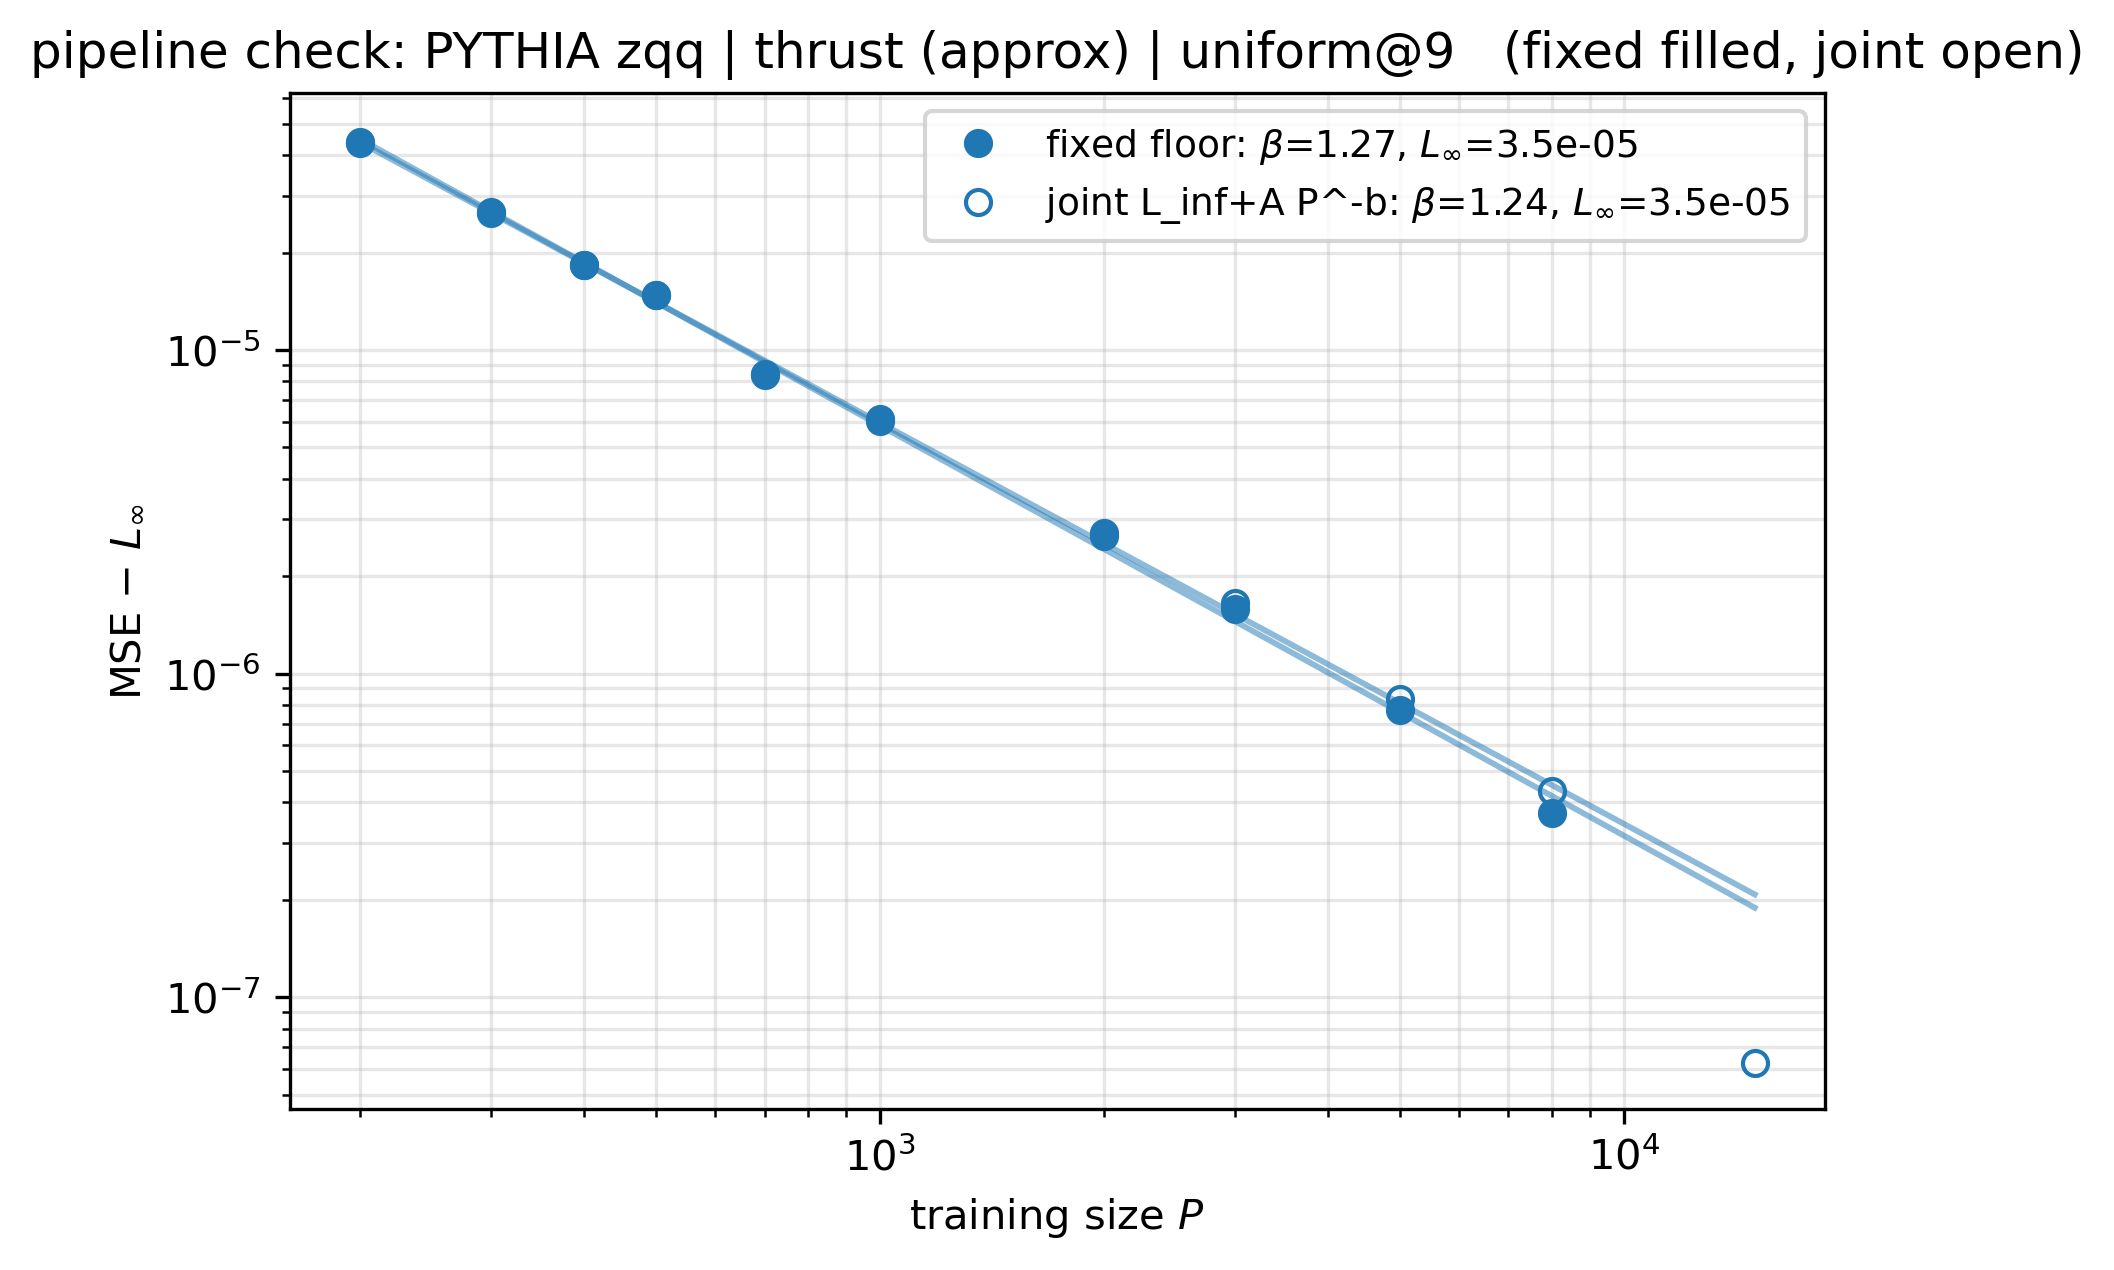

In [9]:
# pipeline check: one curve via the cached engine -- zqq @ N, thrust, uniform@9 whitener, BOTH fits
sizes, mean = curve("pythia_zqq", N, ("uniform", 9))
ff, fp = fit_fixed(sizes, mean), fit_floor_powerlaw(sizes, mean)
print(f"[zqq N={N} | uniform@9]  fit_fixed b={ff['beta']:.3f} Linf={ff['floor']:.2e}   "
      f"fit_floor b={fp['beta']:.3f}+/-{fp['beta_unc']:.3f} Linf={fp['floor']:.2e}")

# both fits on ONE (MSE - L_inf) log-log panel   (fit_fixed filled, fit_floor open)
fig, ax = plt.subplots(figsize=(6.6, 4.4)); P = sizes.astype(float)
for nm, fit, mfc in [("fixed floor", ff, "C0"), ("joint L_inf+A P^-b", fp, "none")]:
    exc = mean - fit["floor"]; g = (P >= 200) & (exc > 0)
    ax.plot(P[g], exc[g], "o", mfc=mfc, mec="C0", ms=6, ls="none",
            label=fr"{nm}: $\beta$={fit['beta']:.2f}, $L_\infty$={fit['floor']:.1e}")
    Pl = np.logspace(np.log10(200), np.log10(P.max()), 50)
    ax.plot(Pl, fit["A"] * Pl ** (-fit["beta"]), "-", color="C0", lw=1.4, alpha=0.5)
ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(alpha=0.3, which="both")
ax.set_xlabel("training size $P$"); ax.set_ylabel(r"MSE $-\ L_\infty$")
ax.set_title("pipeline check: PYTHIA zqq | thrust (approx) | uniform@9   (fixed filled, joint open)")
ax.legend(fontsize=9); plt.show()

### Plots

In [10]:
# Loading data for plot 1: Hgg whitened in various ways.

P1_DATA = "pythia_hgg"
P1_NS   = {"fast": [5, 9, 13], "full": [5, 7, 9, 11, 13, 15]}[run_type]
P1_WHIT = ["standardize", "self", ("uniform", 9), ("uniform", 31)]
WLAB = {"standardize": "standardize", "self": "self", ("uniform", 9): "uniform@9", ("uniform", 31): "uniform@31"}
WCOL = {"standardize": "0.2", "self": "C3", ("uniform", 9): "C0", ("uniform", 31): "C1"}

g1 = {(w, n): curve(P1_DATA, n, w) for n in P1_NS for w in P1_WHIT}
f1 = {k: (fit_fixed(*v), fit_floor_powerlaw(*v)) for k, v in g1.items()}

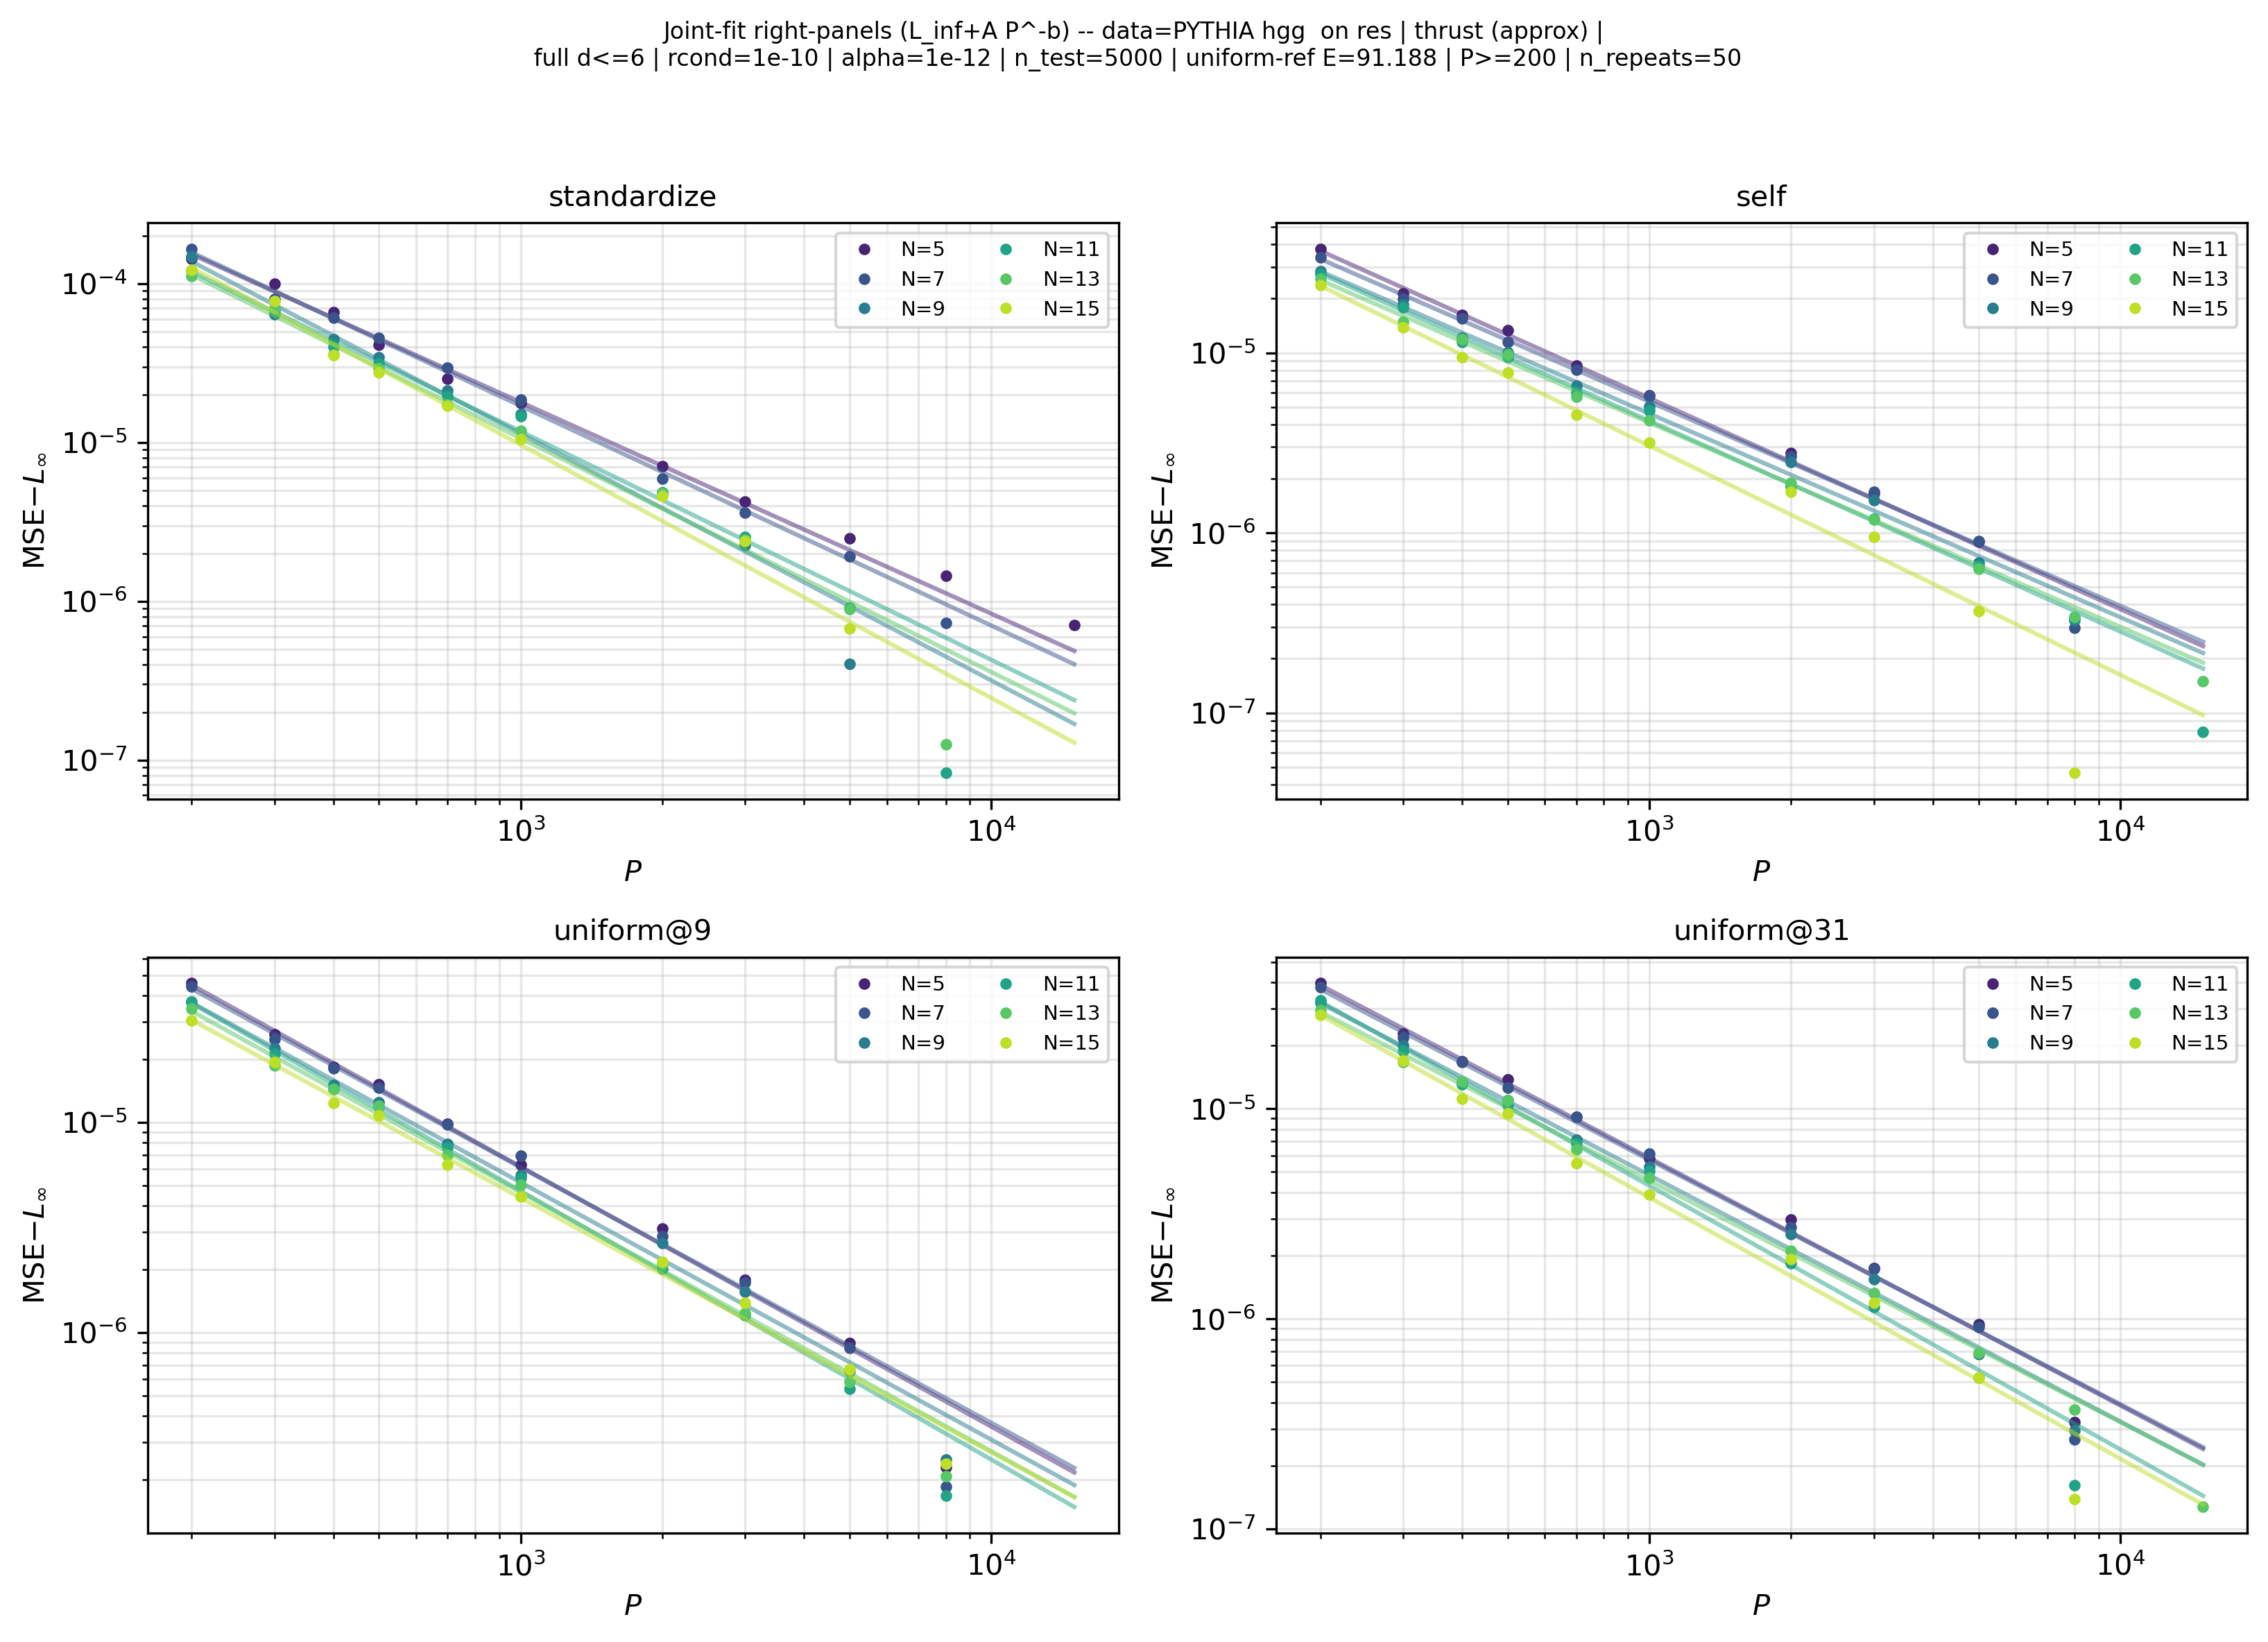

In [11]:
#Joint Fit plots for Hgg
fig, axes = plt.subplots(2, 2, figsize=(11, 8)); axes = axes.ravel()
for ax, w in zip(axes, P1_WHIT):
    for i, n in enumerate(P1_NS):
        (sz, mn), fp = g1[(w, n)], f1[(w, n)][1]; Pp = sz.astype(float)     # [1] = joint fit
        exc = mn - fp["floor"]; gm = (Pp >= 200) & (exc > 0)
        col = plt.cm.viridis(0.1 + 0.8 * i / max(len(P1_NS) - 1, 1))
        ax.plot(Pp[gm], exc[gm], "o", ms=3, color=col, label=f"N={n}")
        if np.isfinite(fp["beta"]):
            Pl = np.logspace(np.log10(200), np.log10(Pp.max()), 40)
            ax.plot(Pl, fp["A"] * Pl ** (-fp["beta"]), "-", color=col, lw=1.5, alpha=0.5)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(alpha=0.3, which="both")
    ax.set_title(WLAB[w], fontsize=10); ax.set_xlabel("$P$"); ax.set_ylabel(r"MSE$-L_\infty$")
    ax.legend(fontsize=7, ncol=2)
fig.suptitle(f"Joint-fit right-panels (L_inf+A P^-b) -- data=PYTHIA hgg  on res | thrust (approx) |\n "
             f"full d<=6 | rcond={RCOND:g} | alpha=1e-12 | n_test=5000 | uniform-ref E=91.188 | P>=200 | "
             f"n_repeats={RUN['n_repeats']}", fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

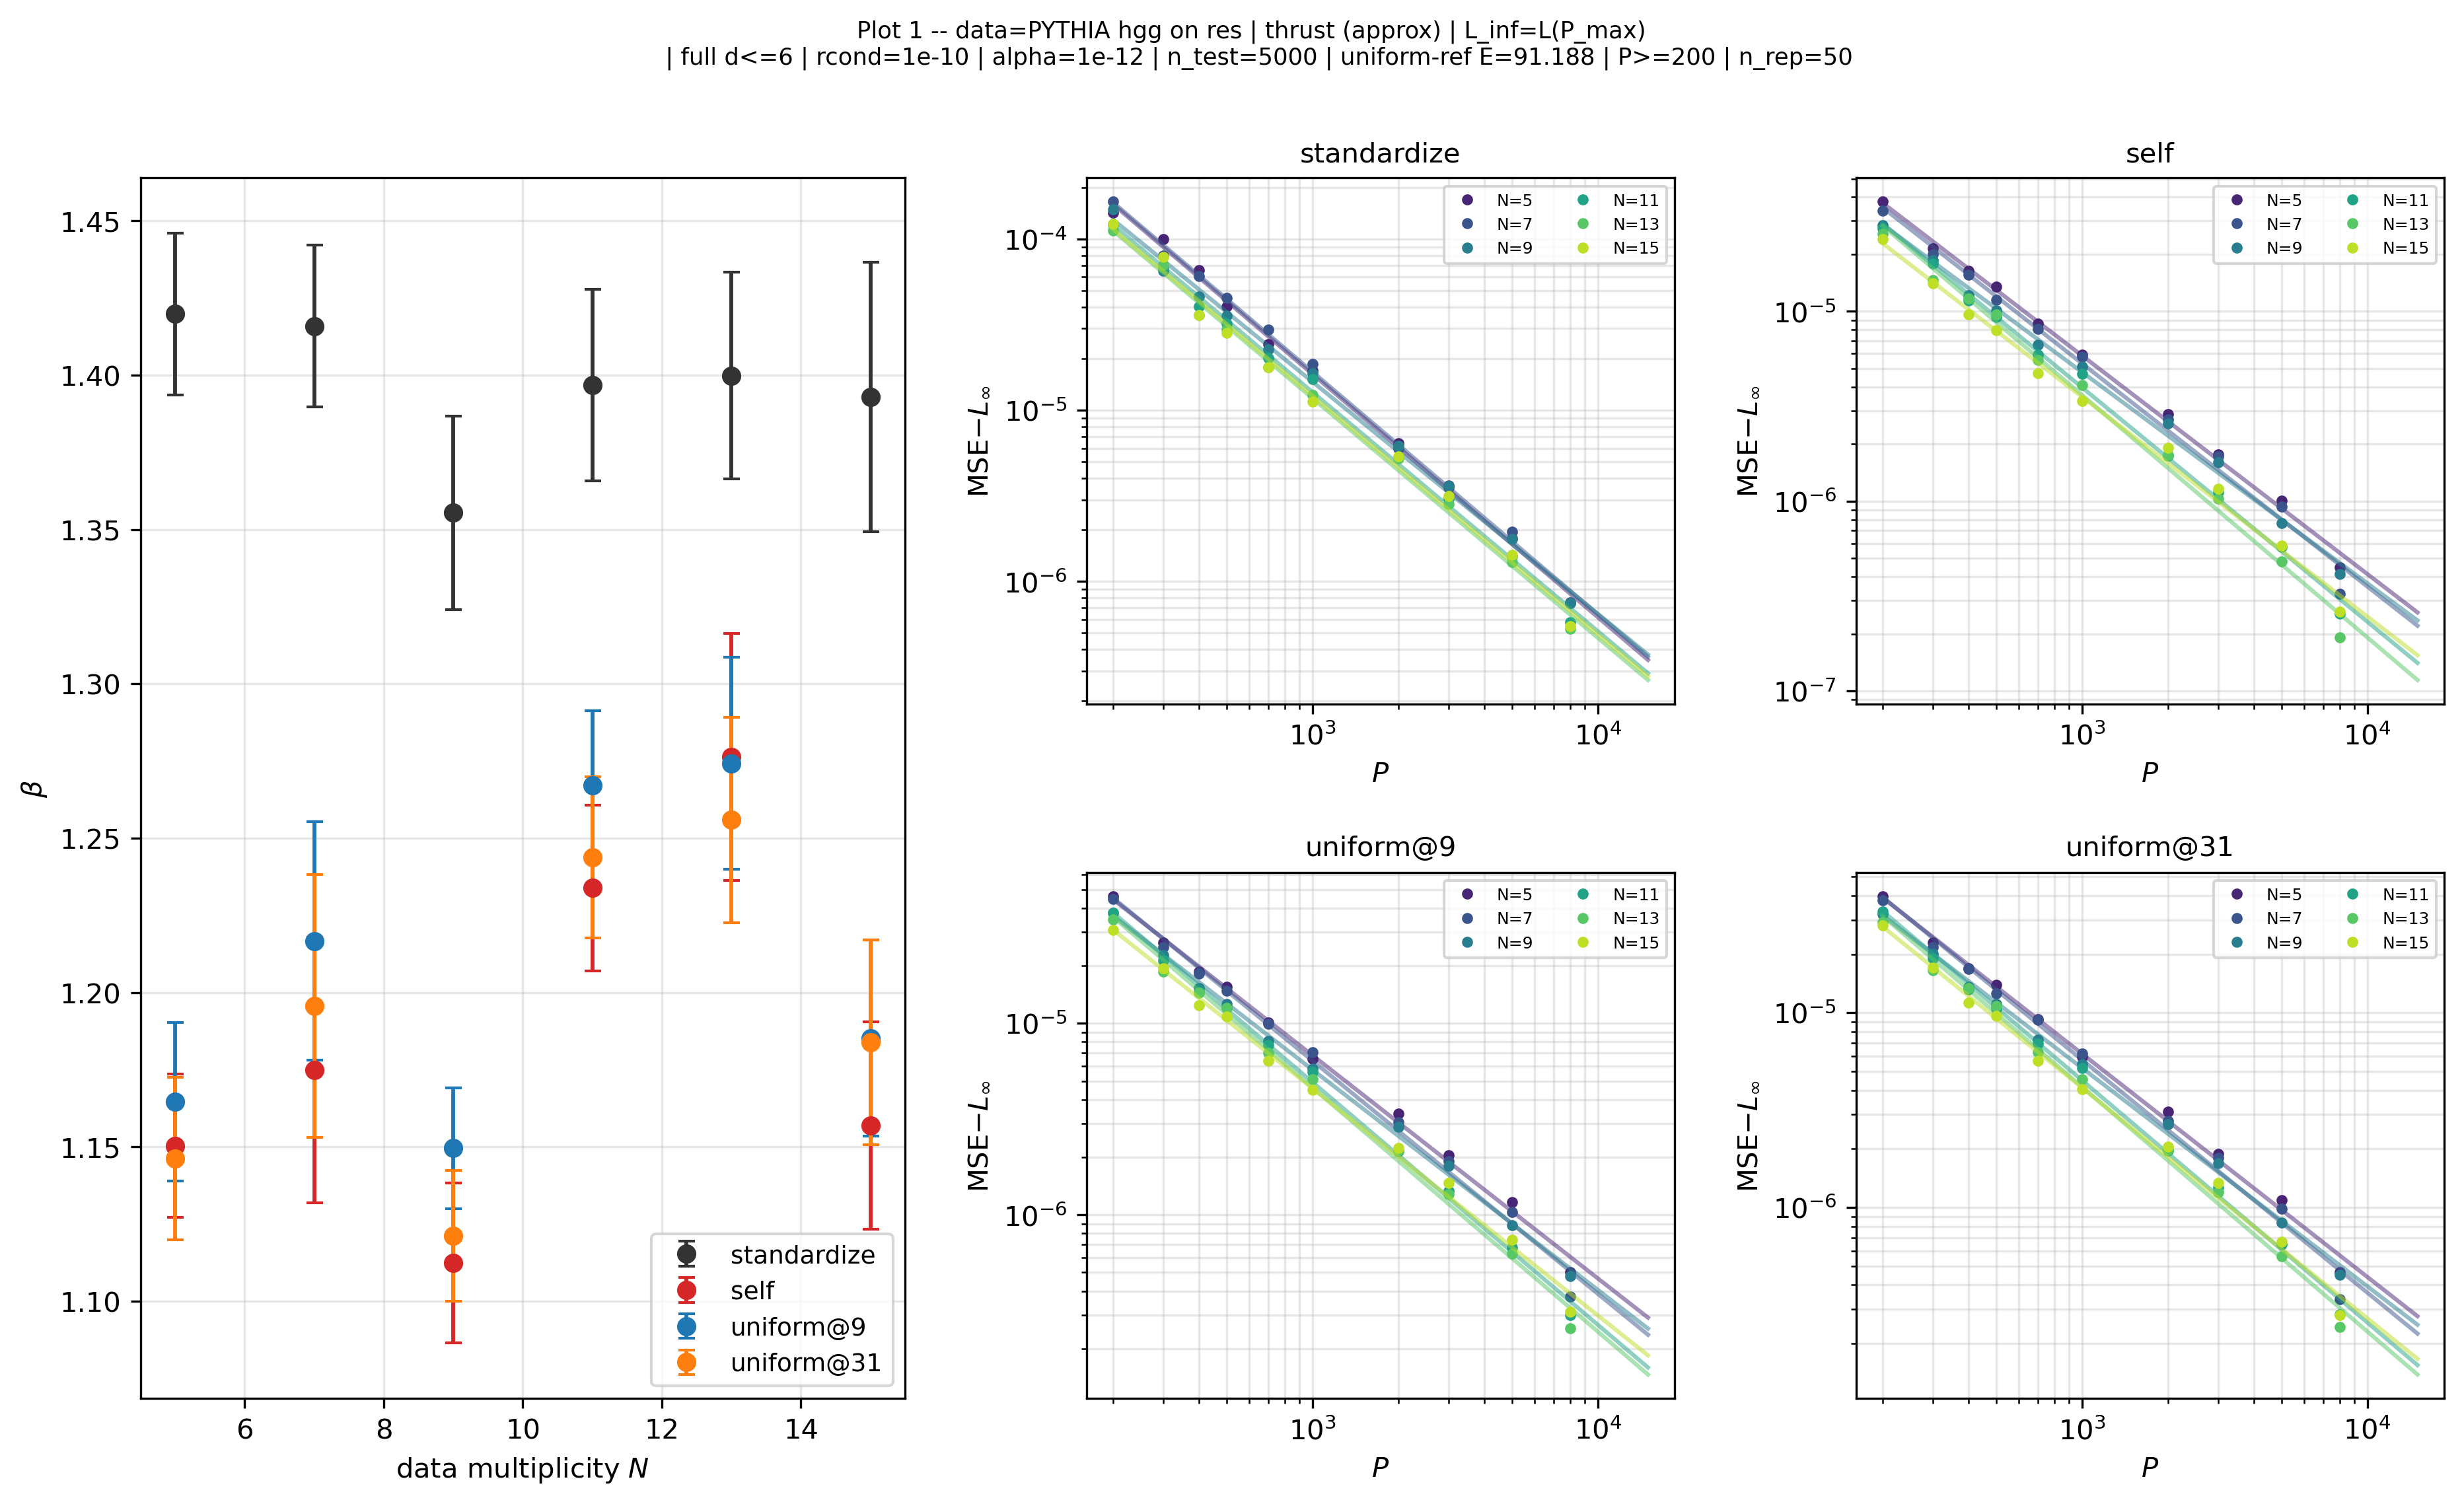

In [12]:
# Plot 1: beta-vs-N (left) + per-whitener (MSE - L_inf)-vs-P facets (right 2x2) -- FIXED-FLOOR fit (f1[..][0])
fig = plt.figure(figsize=(15, 8)); gs = fig.add_gridspec(2, 3, width_ratios=[1.3, 1, 1], hspace=0.32, wspace=0.28)
axB = fig.add_subplot(gs[:, 0])
for w in P1_WHIT:
    c = WCOL[w]
    bf = [f1[(w, n)][0]["beta"] for n in P1_NS]; ef = [f1[(w, n)][0]["beta_unc"] for n in P1_NS]   # [0] = fixed floor
    axB.errorbar(P1_NS, bf, yerr=ef, fmt="o", color=c, capsize=3, lw=1.4, label=WLAB[w])
axB.set_xlabel("data multiplicity $N$"); axB.set_ylabel(r"$\beta$")
# axB.set_title("PYTHIA hgg | thrust : $\\beta$ vs $N$\n(fixed-floor fit, $L_\\infty=L(P_{max})$)")
axB.grid(alpha=0.3); axB.legend(fontsize=9)
facets = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2])]
for ax, w in zip(facets, P1_WHIT):
    for i, n in enumerate(P1_NS):
        (sz, mn), fp = g1[(w, n)], f1[(w, n)][0]; Pp = sz.astype(float)
        exc = mn - fp["floor"]; gm = (Pp >= 200) & (exc > 0)
        col = plt.cm.viridis(0.1 + 0.8 * i / max(len(P1_NS) - 1, 1)); ax.plot(Pp[gm], exc[gm], "o", ms=3, color=col, label=f"N={n}")
        if np.isfinite(fp["beta"]):
            Pl = np.logspace(np.log10(200), np.log10(Pp.max()), 40); ax.plot(Pl, fp["A"] * Pl ** (-fp["beta"]), "-", color=col, lw=1.5, alpha=0.5)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(alpha=0.3, which="both"); ax.set_title(WLAB[w], fontsize=10)
    ax.set_xlabel("$P$"); ax.set_ylabel(r"MSE$-L_\infty$"); ax.legend(fontsize=6, ncol=2)
fig.suptitle(f"Plot 1 -- data=PYTHIA hgg on res | thrust (approx) | L_inf=L(P_max) \n | full d<=6 | rcond={RCOND:g} | "
             f"alpha=1e-12 | n_test=5000 | uniform-ref E=91.188 | P>=200 | "
             f"n_rep={RUN['n_repeats']}", fontsize=8.5)
fig.savefig(FIGDIR / "plot1_beta_vs_N_hgg.png", dpi=105, bbox_inches="tight"); plt.show()

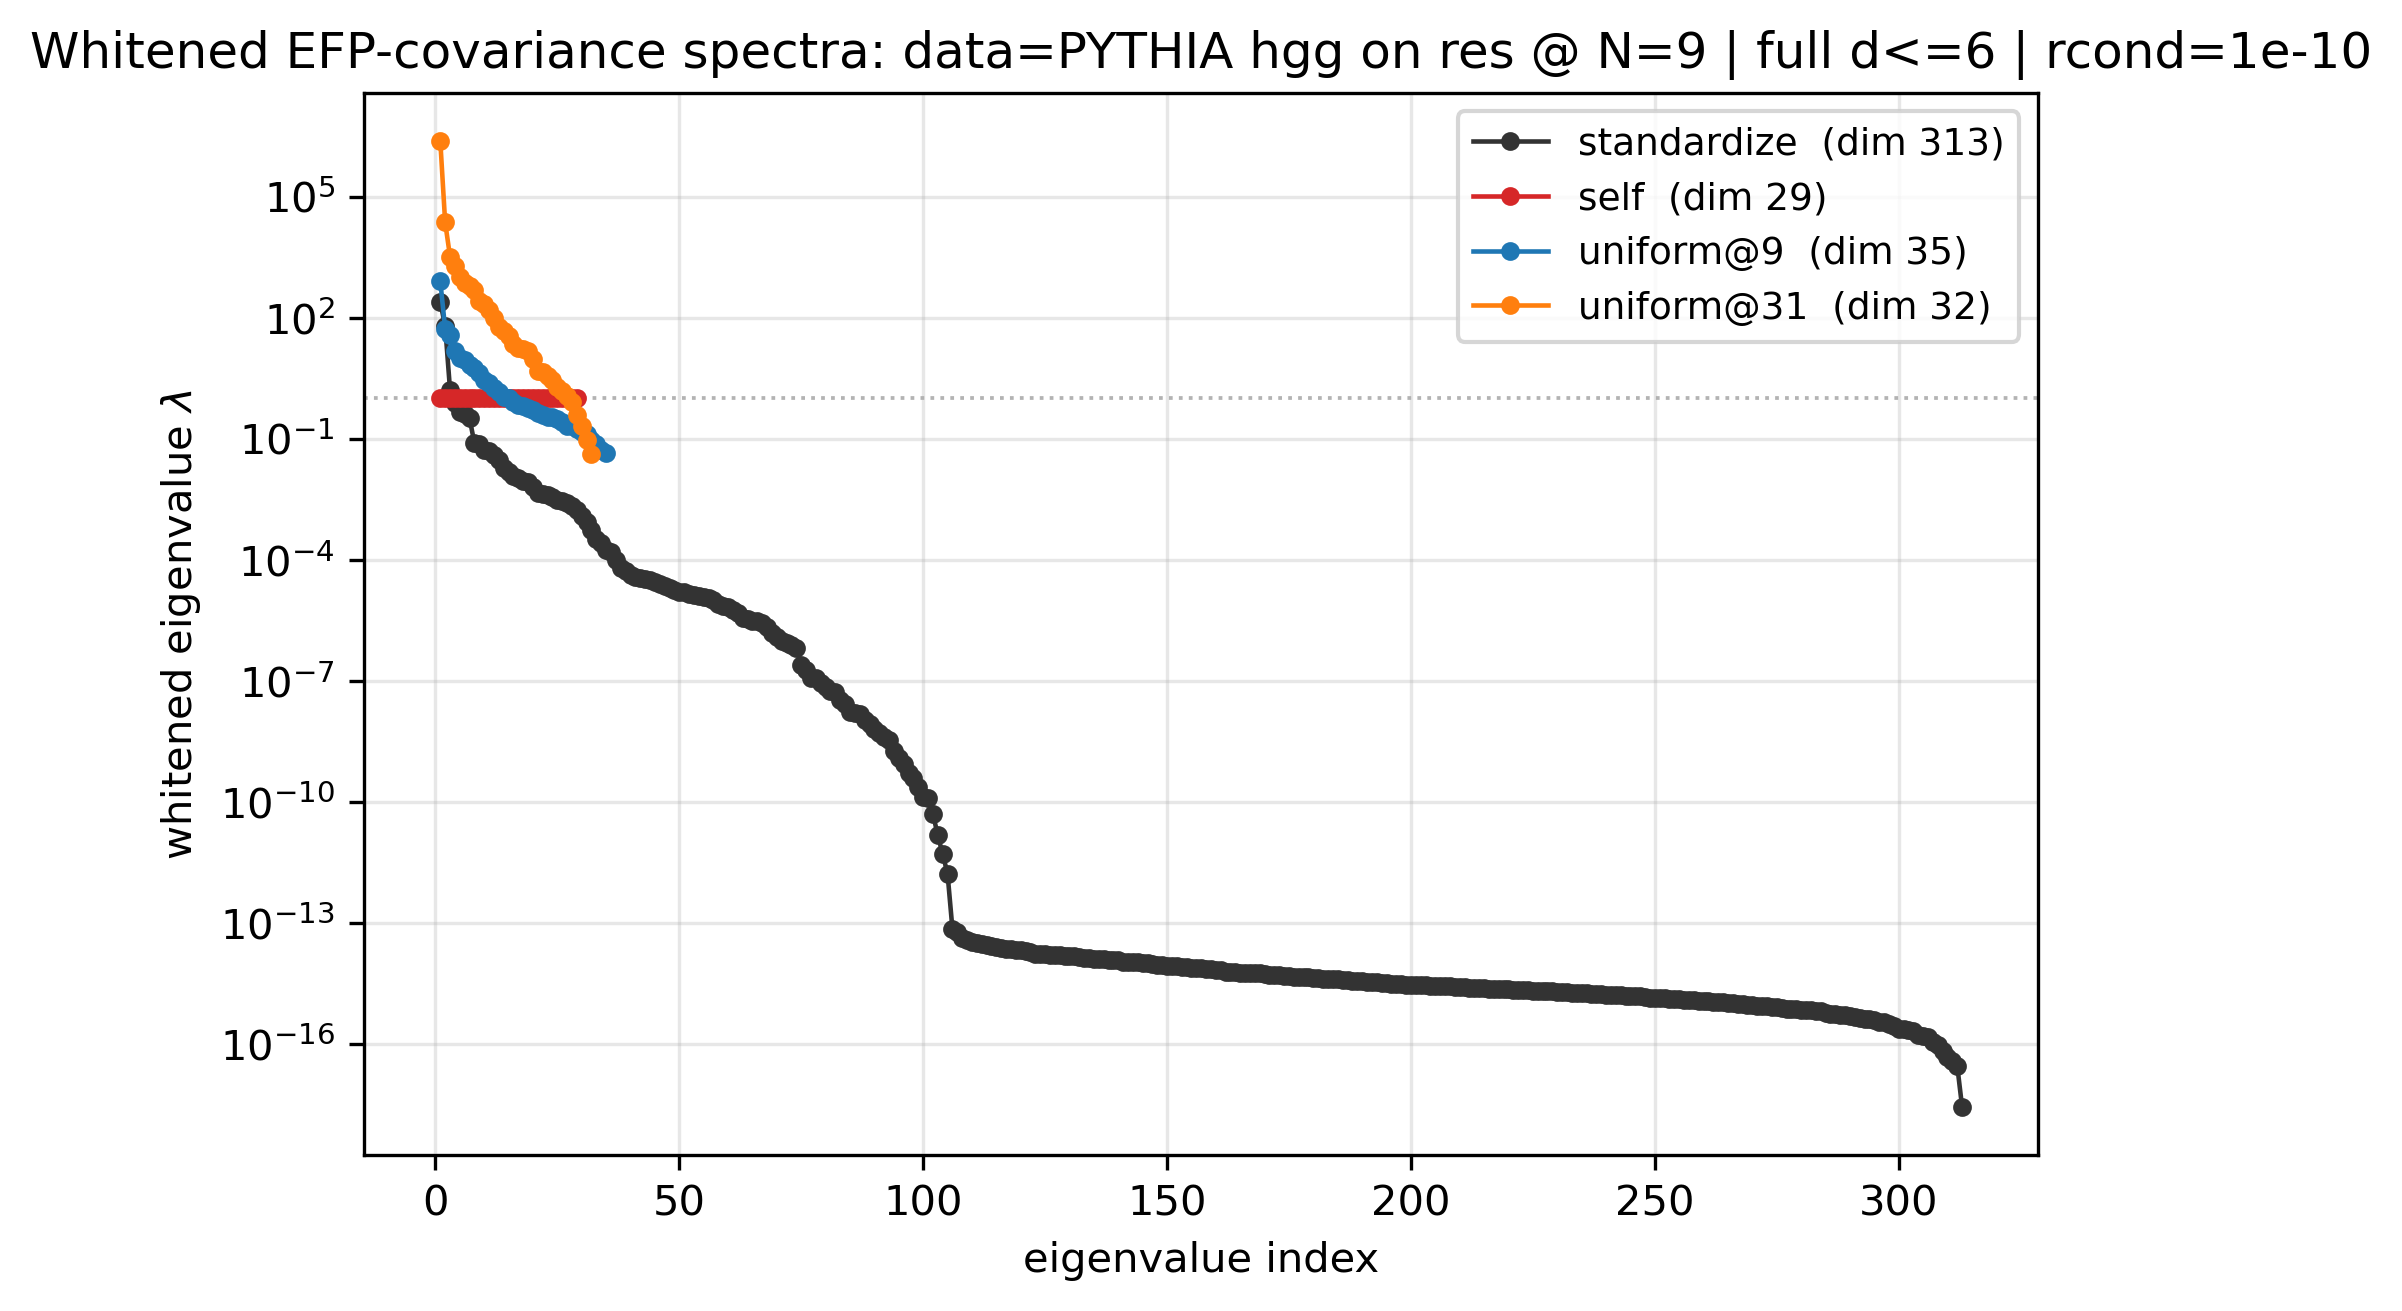

In [13]:
try:
    # spectra of above data-sets (diff whiteners) @ N=9.
    cov_hgg9 = compute_cov(X_hgg['full'][N])

    def whitened_spectrum(kind):
        if kind == "standardize":
            sd = np.sqrt(np.diag(cov_hgg9)); sd[sd == 0] = 1.0
            cw = cov_hgg9 / np.outer(sd, sd)                      # standardized cov = correlation matrix
        elif kind == "self":
            W, _ = compute_whitener(cov_hgg9); cw = whiten_cov(cov_hgg9, W)     # self on the FULL cov -> ~I
        else:
            W, _, _ = make_whitener(kind, None); cw = whiten_cov(cov_hgg9, W)   # uniform reference
        return np.sort(np.abs(np.linalg.eigvalsh(cw)))[::-1]      # |eigenvalues|, descending

    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    for kind in P1_WHIT:
        lam = whitened_spectrum(kind)
        ax.plot(np.arange(1, len(lam) + 1), lam, "o-", ms=3.5, lw=1.1, color=WCOL[kind],
                label=f"{WLAB[kind]}  (dim {len(lam)})")
    ax.axhline(1.0, color="0.7", lw=0.9, ls=":", zorder=0)        # self-whitening -> lambda = 1
    ax.set_yscale("log"); ax.grid(alpha=0.3, which="both")
    ax.set_xlabel("eigenvalue index"); ax.set_ylabel(r"whitened eigenvalue $\lambda$")
    ax.set_title(f"Whitened EFP-covariance spectra: data=PYTHIA hgg on res @ N={N} | full d<=6 | rcond={RCOND:g}")
    ax.legend(fontsize=9)
    # fig.savefig(FIGDIR / "spectra_hgg_N9.png", dpi=110, bbox_inches="tight")
    plt.show()
except (NameError, FileNotFoundError) as _e:
    print('[note] whitened-spectra plot needs raw PYTHIA (X_hgg) -> skipped on this data-less clone; the committed figure output shows the rendered result' + f'  ({type(_e).__name__})')

In [14]:
# Loading data for plot 2: Hgg data whitened with diff whiteners beta vs N_W.
P2_N = 9
P2_NW = {"uniform": REF_NW["uniform"],
         "pythia_zqq": [nw for nw in REF_NW["pythia_zqq"] if nw != P2_N],   # drop zqq@N (= the self slot)
         "pythia_hgg": REF_NW["pythia_hgg"]}
if run_type == "fast":
    P2_NW = {k: v[::2] for k, v in P2_NW.items()}
P2_SRC = [("uniform", "C0", "uniform@Nw"), ("pythia_zqq", "C3", "zqq@Nw"), ("pythia_hgg", "C2", "hgg@Nw")]

g2 = {(src, nw): curve("pythia_zqq", P2_N, (src, nw)) for src, _, _ in P2_SRC for nw in P2_NW[src]}
f2 = {k: fit_fixed(*v) for k, v in g2.items()}   # fixed-floor fit only (L_inf = L(P_max))


/tmp/ipykernel_2583747/300619369.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.90])


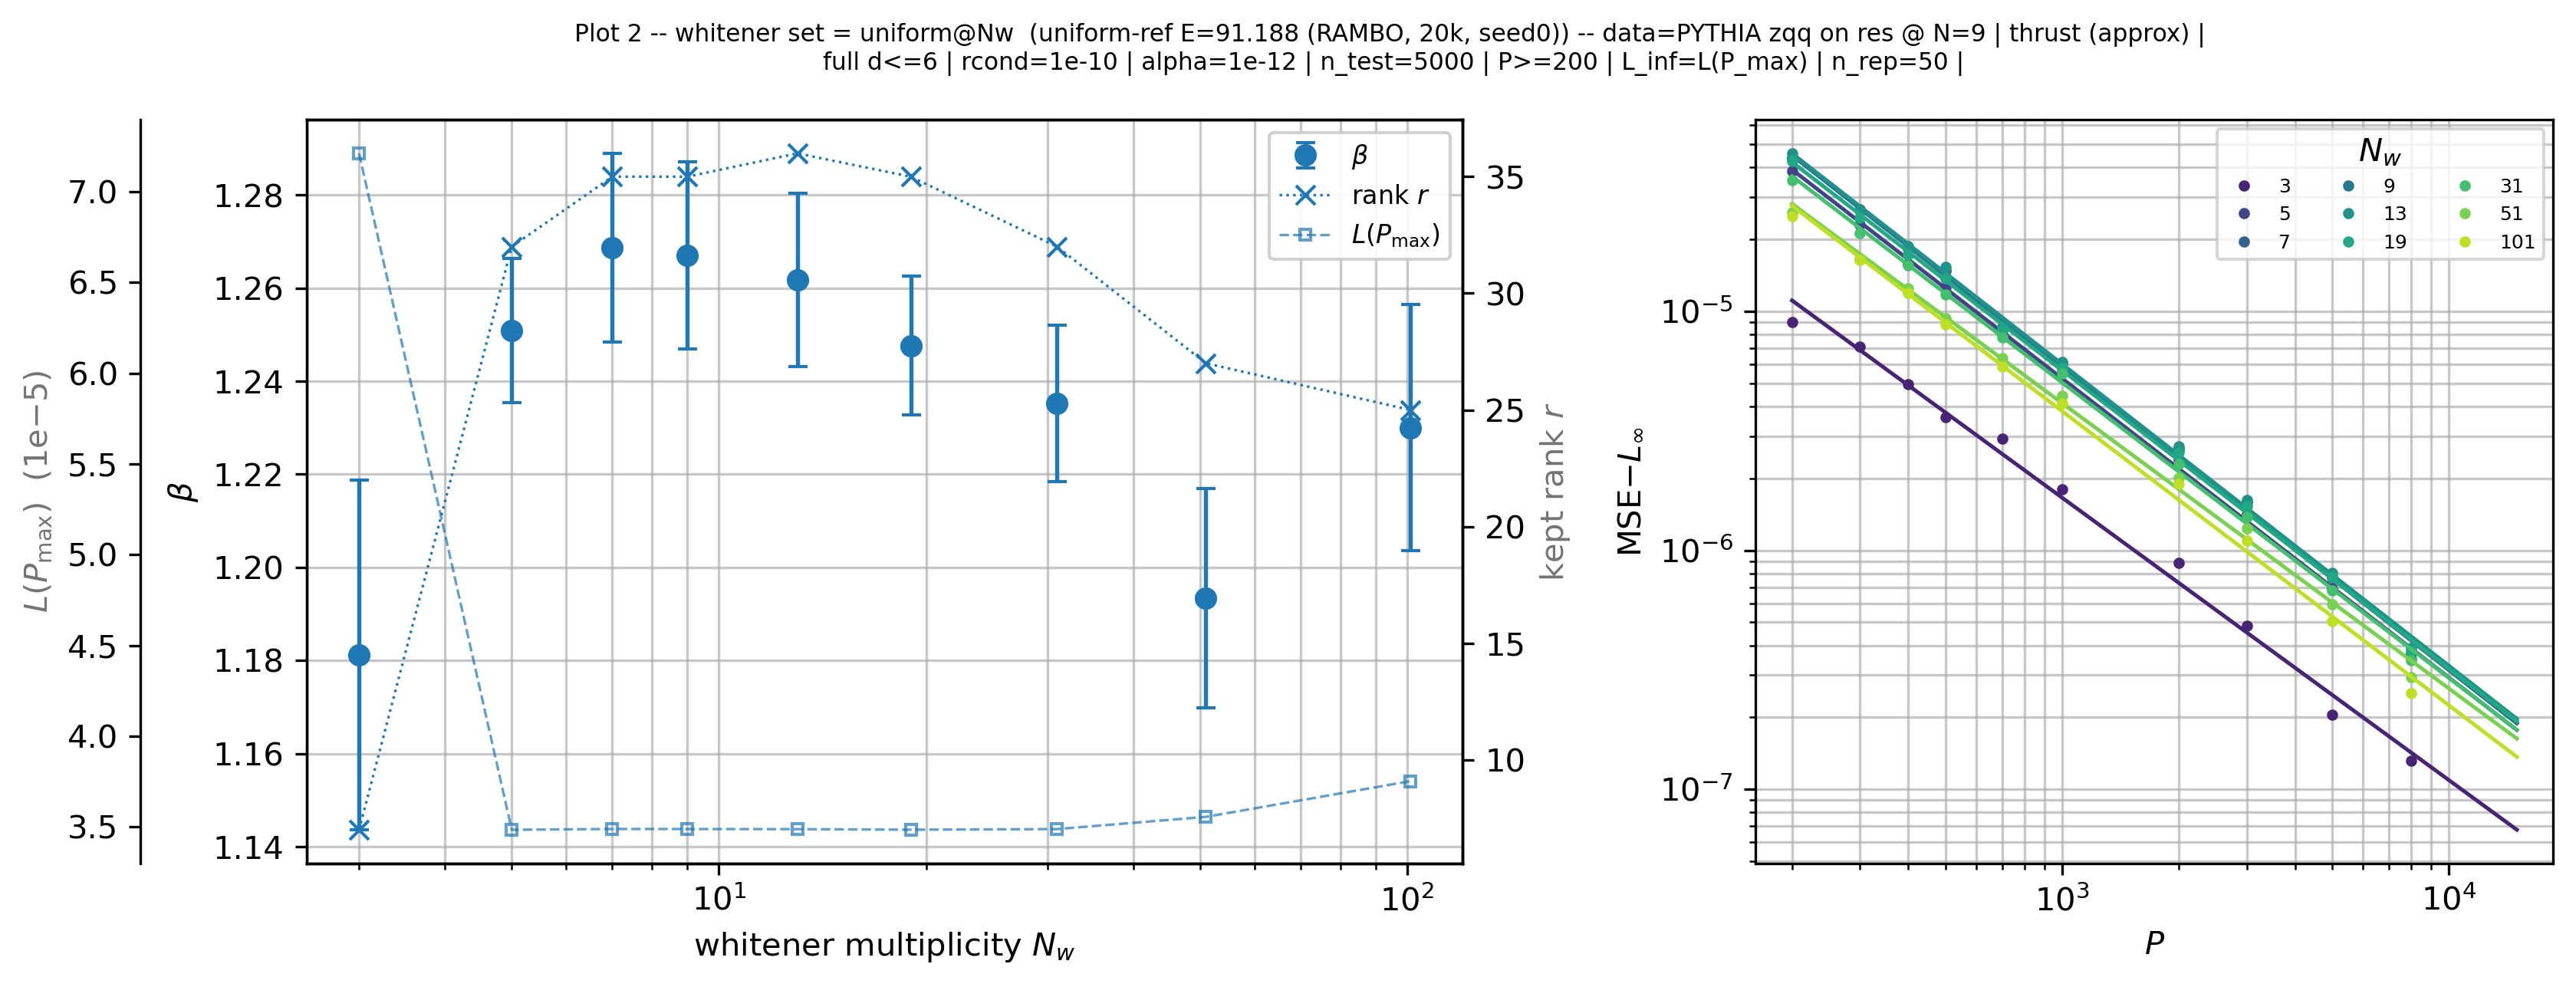

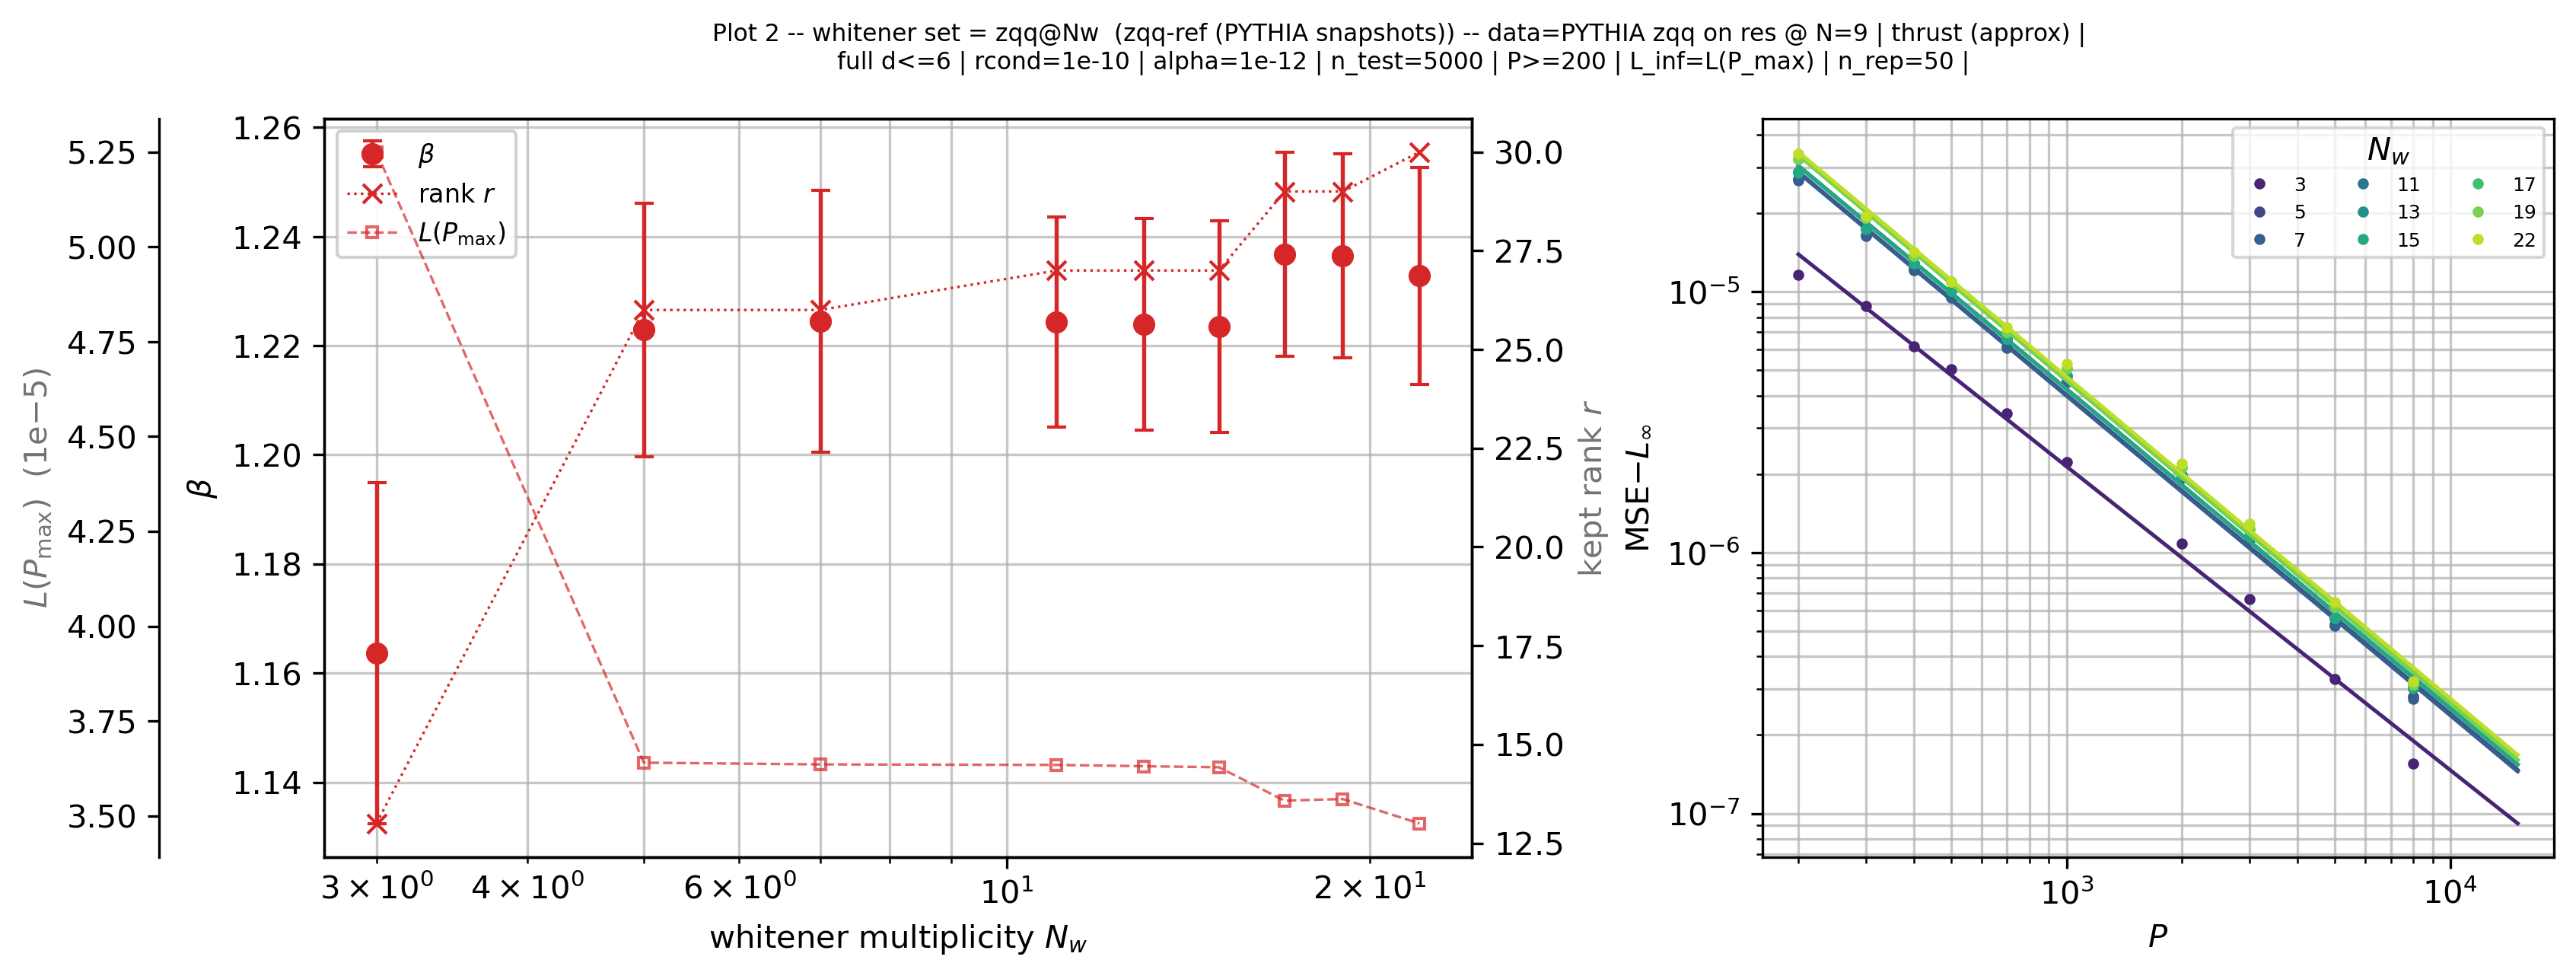

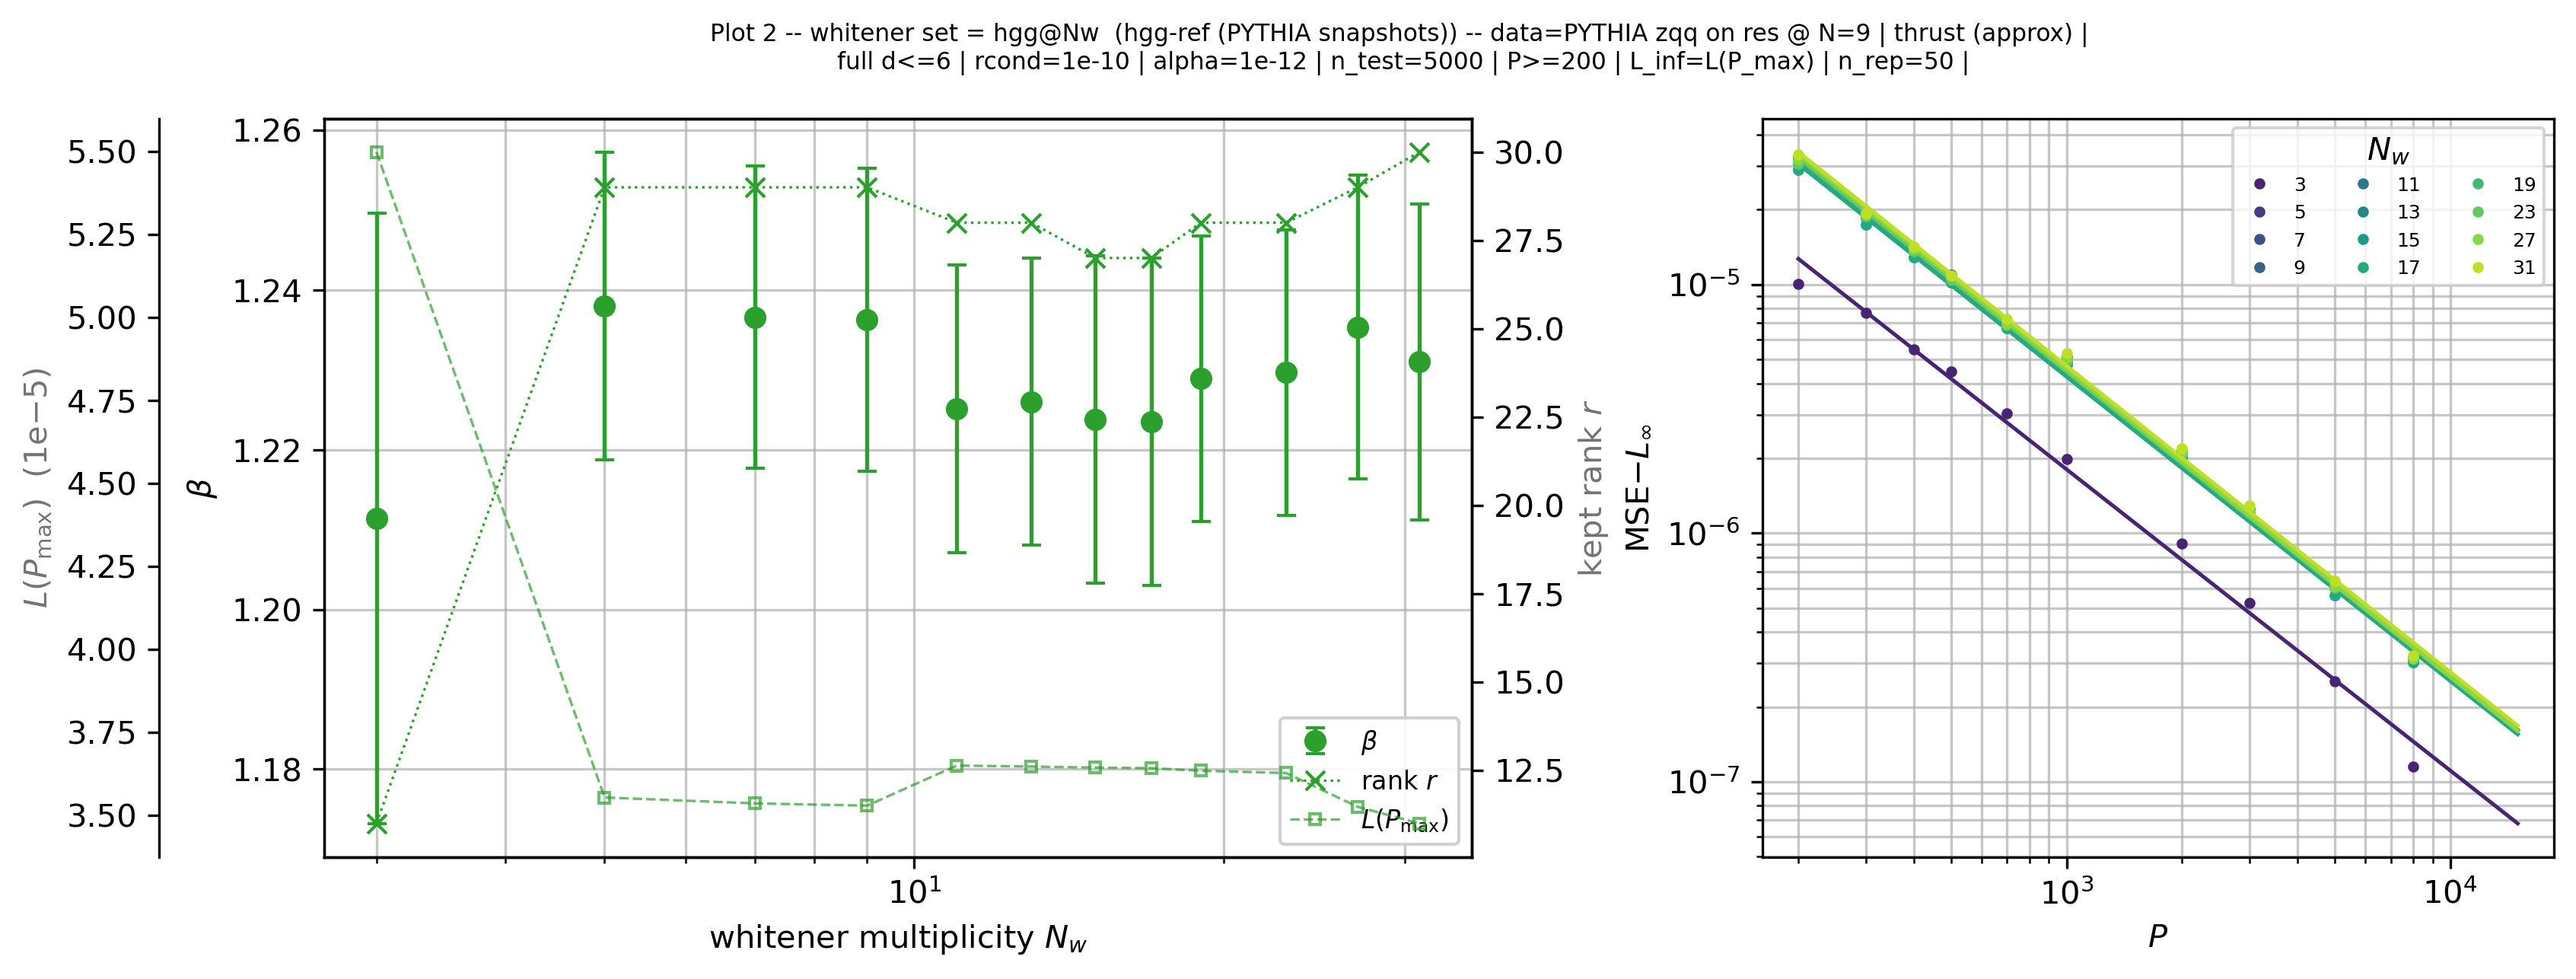

In [15]:
try:
    # Plot 2
    REF_NOTE = {"uniform": "uniform-ref E=91.188 (RAMBO, 20k, seed0)",
                "pythia_zqq": "zqq-ref (PYTHIA snapshots)", "pythia_hgg": "hgg-ref (PYTHIA snapshots)"}
    for src, col, lab in P2_SRC:
        nws = P2_NW[src]
        fig = plt.figure(figsize=(12.6, 4.2)); gs = fig.add_gridspec(1, 2, width_ratios=[1.45, 1], wspace=0.3)
        # left: beta vs N_w  (+ kept rank r on the right twin axis, L_inf on a far-left twin axis)
        axB = fig.add_subplot(gs[0, 0]); axR = axB.twinx()
        axL = axB.twinx()                                                  # third axis: L_inf, on the FAR LEFT
        axL.yaxis.set_label_position("left"); axL.yaxis.tick_left()
        axL.spines["left"].set_position(("outward", 52))
        bf = [f2[(src, nw)]["beta"] for nw in nws]; ef = [f2[(src, nw)]["beta_unc"] for nw in nws]
        Li = [f2[(src, nw)]["floor"] for nw in nws]                        # L_inf = L(P_max)
        # legend now names the THREE series drawn on the left panel (beta / kept rank r / L(P_max)),
        # not the whitener set (that's in the suptitle).  Succinct labels so they don't crowd the points.
        hB = axB.errorbar(nws, bf, yerr=ef, fmt="o", color=col, capsize=3, lw=1.3, label=r"$\beta$")        # fixed floor
        hR, = axR.plot(nws, [r_of((src, nw)) for nw in nws], "x:", color=col, lw=0.8, alpha=1, label=r"rank $r$")  # r(N_w)
        hL, = axL.plot(nws, Li, "s--", color=col, lw=0.8, ms=3.5, mfc="none", alpha=0.7, label=r"$L(P_{\max})$")   # L_inf(N_w)
        axB.set_xscale("log"); axB.set_xlabel(r"whitener multiplicity $N_w$")
        axB.set_ylabel(r"$\beta$"); axR.set_ylabel(r"kept rank $r$", color="0.45")
        # fold axL's sci-notation scale factor into ITS label -- the auto "1e-5" offset text renders at
        # axB's spine (axes-x=0), so it reads as beta's scale; hide it and put it where L_inf actually is.
        fig.canvas.draw()
        _off = axL.yaxis.get_offset_text().get_text()                     # e.g. "1e-5" (belongs to L_inf)
        axL.yaxis.offsetText.set_visible(False)
        axL.set_ylabel(r"$L(P_{\max})$" + (f"  ({_off})" if _off else ""), color="0.45")
        #axB.set_title(r"$\beta$ vs $N_w$");
        axB.grid(alpha=0.7, which="both")
        axB.legend(handles=[hB, hR, hL], fontsize=8, loc="best", framealpha=0.9)
        # right: the (MSE - L_inf)-vs-P curves this beta was fit from
        ax = fig.add_subplot(gs[0, 1])
        for i, nw in enumerate(nws):
            (sz, mn), fp = g2[(src, nw)], f2[(src, nw)]; Pp = sz.astype(float)
            exc = mn - fp["floor"]; gm = (Pp >= 200) & (exc > 0)
            c = plt.cm.viridis(0.1 + 0.8 * i / max(len(nws) - 1, 1)); ax.plot(Pp[gm], exc[gm], "o", ms=2.5, color=c, label=f"{nw}")
            if np.isfinite(fp["beta"]):
                Pl = np.logspace(np.log10(200), np.log10(Pp.max()), 40); ax.plot(Pl, fp["A"] * Pl ** (-fp["beta"]), "-", color=c, lw=1.2, alpha=1)
        ax.set_xscale("log"); ax.set_yscale("log"); ax.grid(alpha=0.7, which="both"); 
        #ax.set_title(r"MSE$-L_\infty$ vs $P$", fontsize=10)
        ax.set_xlabel("$P$"); ax.set_ylabel(r"MSE$-L_\infty$"); ax.legend(fontsize=6, ncol=3, title=r"$N_w$")
        fig.suptitle(f"Plot 2 -- whitener set = {lab}  ({REF_NOTE[src]}) -- data=PYTHIA zqq on res @ N=9 | thrust (approx) | \n"
                     f"full d<=6 | rcond={RCOND:g} | alpha=1e-12 | n_test=5000 | P>=200 | L_inf=L(P_max) | "
                     f"n_rep={RUN['n_repeats']} |", fontsize=7.5)
        fig.tight_layout(rect=[0, 0, 1, 0.90])
        fig.savefig(FIGDIR / f"plot2_beta_vs_Nw_zqq_{src.replace('pythia_','')}.png", dpi=105, bbox_inches="tight")
        plt.show()
except (NameError, FileNotFoundError) as _e:
    print('[note] Plot 2 per-whitener figures need raw PYTHIA for the rank-r axis -> skipped on this data-less clone; see the committed outputs + the combined beta-vs-N_w plot' + f'  ({type(_e).__name__})')

#### Plot 2 Interpretation
The interesting trend that we see in the above set of plots, which is the reason why I included them here, is that we see a clear corellation between the number of kept features and the learned slope. This happens while the disposed directions have very small eigenvalues. I wonder if: this is something that we expect, or is it a fiting artifact? I doubt the latter, especially since the $L(P_{\rm max\it})$ does not show a corellation. I think this is a clear direction to investigate.

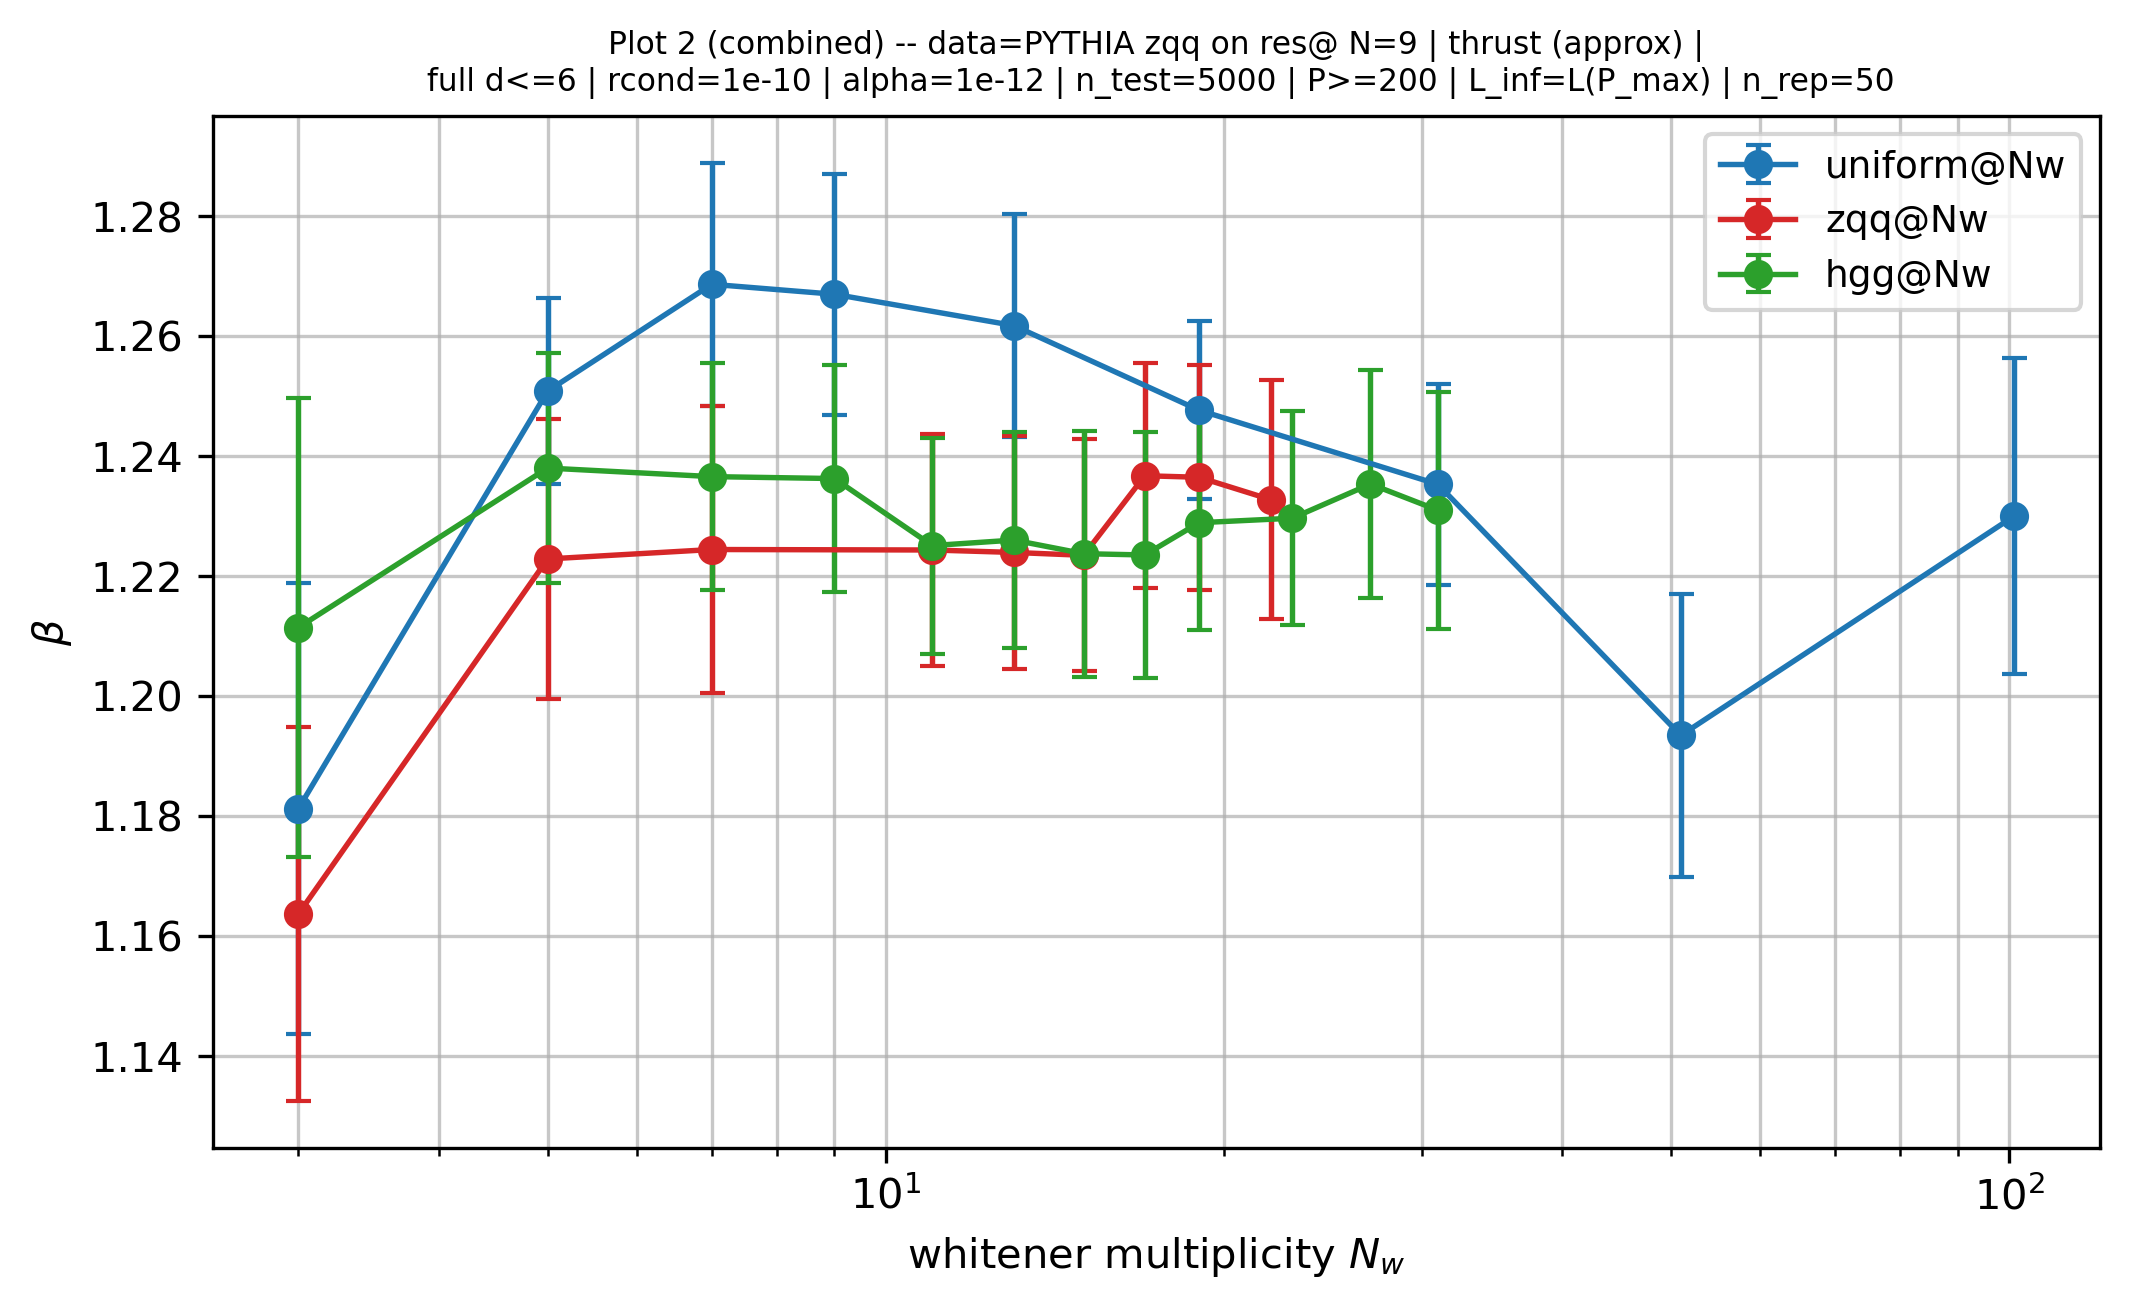

In [16]:
# Plot 2 (combined)
fig, axB = plt.subplots(figsize=(7.2, 4.8))
for src, col, lab in P2_SRC:
    nws = P2_NW[src]
    bf = [f2[(src, nw)]["beta"]     for nw in nws]
    ef = [f2[(src, nw)]["beta_unc"] for nw in nws]
    axB.errorbar(nws, bf, yerr=ef, fmt="o-", color=col, capsize=3, lw=1.3, label=lab)
axB.set_xscale("log"); axB.set_xlabel(r"whitener multiplicity $N_w$")
axB.set_ylabel(r"$\beta$")
axB.grid(alpha=0.7, which="both"); axB.legend(fontsize=9, loc="best")
axB.set_title(f"Plot 2 (combined) -- data=PYTHIA zqq on res@ N=9 | thrust (approx) |\n "
             f"full d<=6 | rcond={RCOND:g} | alpha=1e-12 | n_test=5000 | P>=200 | L_inf=L(P_max) | "
             f"n_rep={RUN['n_repeats']}", fontsize=7.5)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(FIGDIR / "plot2_beta_vs_Nw_combined.png", dpi=105, bbox_inches="tight")
plt.show()